RMS difference between model and measured ORM: 7.652e-05 m
Plot saved to: output/orms_comparison.png


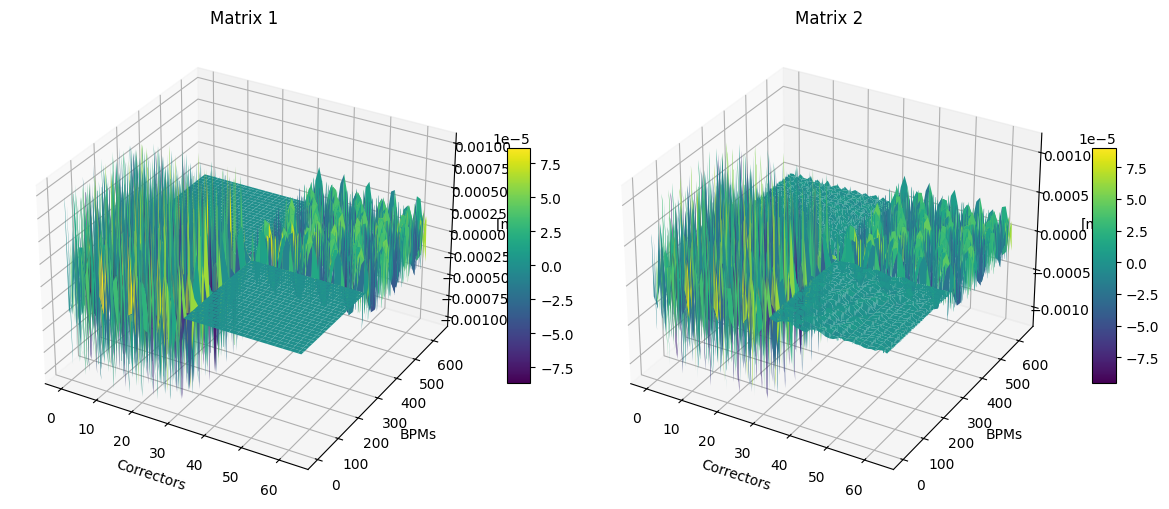

In [23]:
import os
import h5py
import numpy as np
import at
from pyLOCO.helpers import load_config
from pyLOCO.pyloco import remove_bad_bpms, pyloco,last_by_sorted_key, get_quads_block, save_fit_dict, get_fit_param_block
from pyLOCO.analysis import plot_orm_bars_simone_style, plot_beta, plot_eta, plot_matrices
from pyLOCO.response_matrix import response_matrix
from pyloco_config import FitInitConfig, RMConfig, fixed_parameters, loco_options
import matplotlib.pyplot as plt

# --- Load configuration ---
config_path = os.path.abspath("pyloco_config.py")
load_config(config_path=config_path)
## 96 - 32(skew) + normal
# --- Load lattice ---
ring = at.load_lattice('betamodel.mat', use='betamodel')
ring.disable_6d()
# --- Get element indices ---
elements_ind = at.get_refpts(ring, "*")
cor_indices = at.get_refpts(ring, 'S[FIJ]2A*')
Corords = [cor_indices,cor_indices]
used_bpm = at.get_refpts(ring, at.elements.Monitor)
quad_indices = at.get_refpts(ring, at.elements.Quadrupole)
QD3 = at.get_refpts(ring, 'QD3[AE]*')
QF4 = at.get_refpts(ring, 'QF4[ABDE]*')
QD5 = at.get_refpts(ring, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
quad_indices = at.get_refpts(ring, at.elements.Quadrupole)
CAVords = at.get_refpts(ring, at.elements.RFCavity)
sext_indices = at.get_refpts(ring, at.elements.Sextupole)
skew_ord = at.get_refpts(ring, 'S[HFDIJ]*')

# --- Load measurements ---
with h5py.File("./data/ORM_for_pyLOCO_20251110_211751.h5", "r") as f:
    measured_orm = np.array(f["response_matrix"])  # [BPMs x COR]
    delta_correctors = np.array(f["full_delta"])

with h5py.File("./data/measured_dispersion_loco_211751.h5", "r") as f:
    measured_eta_x_ = np.array(f["measured_eta_x"])
    measured_eta_y_ = np.array(f["measured_eta_y"])
    rf_full_step = np.array(f.attrs["rf_full_step"])

with h5py.File("./data/measured_BPM_noise_loco_174636.h5", "r") as f:  # in meter
    Noise_BPMx = np.array(f["Noise_BPMx"])
    Noise_BPMy = np.array(f["Noise_BPMy"])


# --- Remove bad BPMs ---

bad_bpm_positions = np.array([27, 231, 286]) # remove 58

used_bpms_ords = np.delete(used_bpm, bad_bpm_positions)
Noise_BPMx_cleaned = np.delete(Noise_BPMx, bad_bpm_positions)
Noise_BPMy_cleaned = np.delete(Noise_BPMy, bad_bpm_positions)
sigma_w = np.concatenate((Noise_BPMx_cleaned, Noise_BPMy_cleaned))[:,
          np.newaxis]  # Note: weight matrix shape for pyloco

measured_eta_x = np.delete(measured_eta_x_, bad_bpm_positions)
measured_eta_y = np.delete(measured_eta_y_, bad_bpm_positions)
eta = np.concatenate([measured_eta_x, measured_eta_y])


measured_orm, removed = remove_bad_bpms(
    measured_orm,
    bad_bpm_positions,
    total_bpms=len(used_bpm),
    axis=0,
    input_type="positions"
)

# if include dispersion is true
#measured_orm = np.hstack((measured_orm, eta.reshape(-1, 1)))

# --- Prepare configuration for model ORM ---

CMstep = [[delta_correctors] * len(Corords[0]), [delta_correctors] * len(Corords[1])]

fit_cfg = FitInitConfig()
includeDispersion = False
HCMCoupling = np.zeros(len(Corords[0]))
VCMCoupling = np.zeros(len(Corords[1]))

cfg = RMConfig(
    dkick=CMstep,
    bpm_ords=used_bpms_ords,
    cm_ords=Corords,
    HCMCoupling=HCMCoupling,
    VCMCoupling=VCMCoupling,
    rfStep=rf_full_step,
    includeDispersion=includeDispersion
)

# --- Compute model ORM ---

orm_model = response_matrix(ring, config=cfg)
rms_diff = np.sqrt(np.mean((orm_model - measured_orm)**2))
print(f"RMS difference between model and measured ORM: {rms_diff:.3e} m")
os.makedirs("output", exist_ok=True)
plot_matrices(orm_model, measured_orm, titles=None, cmap='viridis', plot_type='3d', save_path="output/orms_comparison.png")


==== Iteration 1/2 – LM ====
   No outliers in the data set.
Initial Chi²: 8.5681e+04


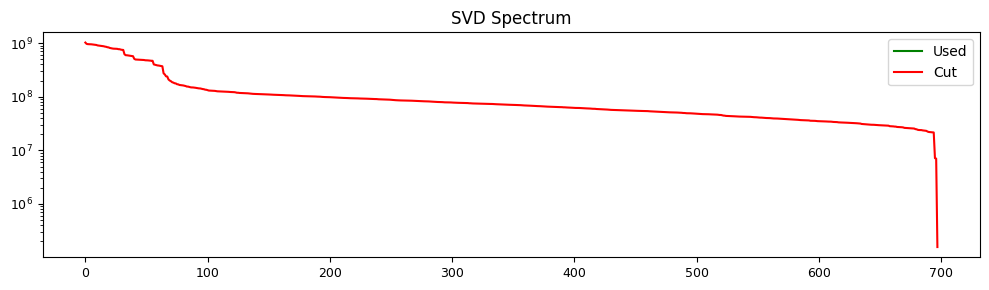

  LM inner 1: chi² 8.5681e+04 (previous 8.5681e+04), λ=0.001


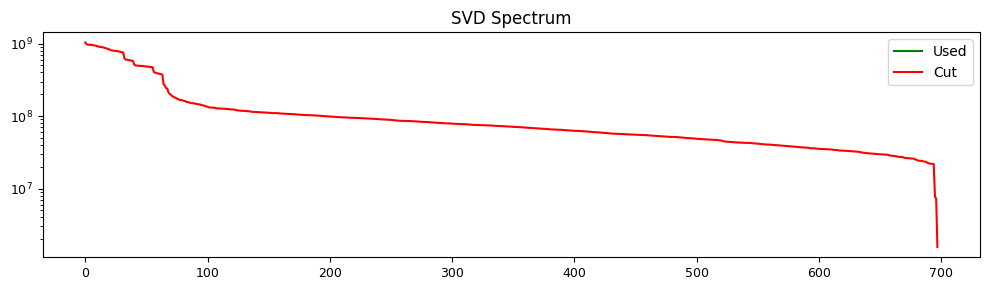

  LM inner 2: chi² 8.5681e+04 (previous 8.5681e+04), λ=0.01


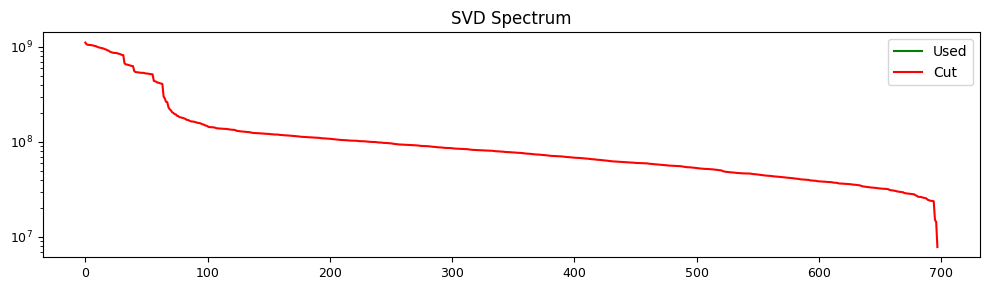

  LM inner 3: chi² 8.5681e+04 (previous 8.5681e+04), λ=0.1


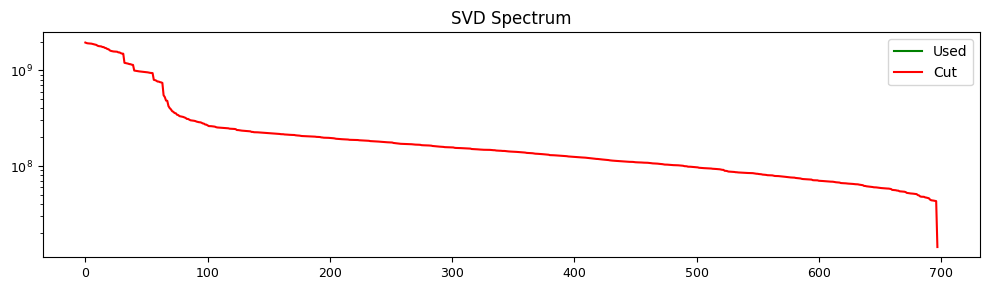

  LM inner 4: chi² 8.5681e+04 (previous 8.5681e+04), λ=1


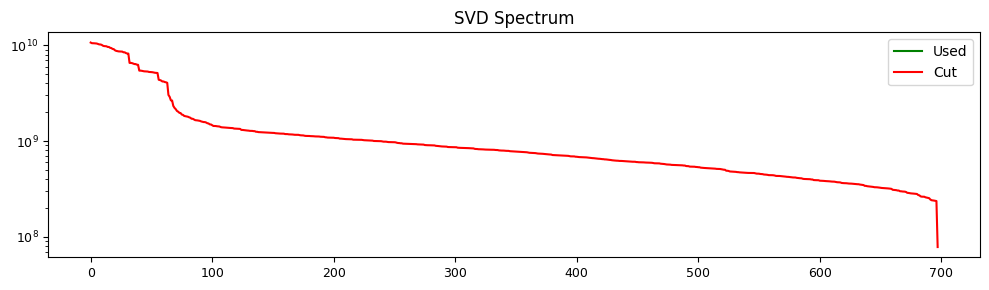

  LM inner 5: chi² 8.5681e+04 (previous 8.5681e+04), λ=10
  λ exceeded maximum; stop inner loop.
Chi² after correction: 8.5681e+04

==== Iteration 2/2 – LM ====
   No outliers in the data set.
Initial Chi²: 8.5681e+04


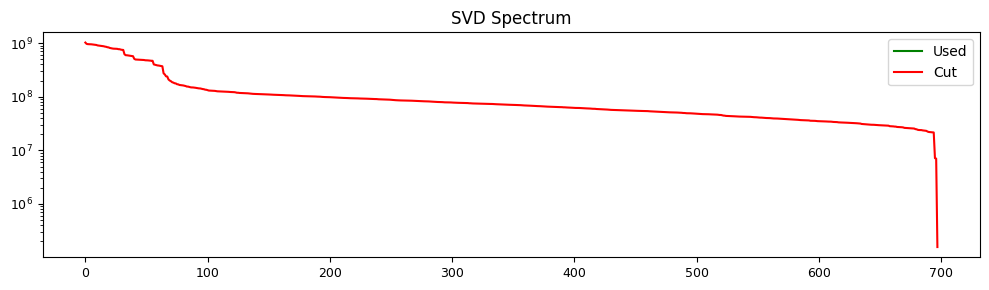

  LM inner 1: chi² 8.5681e+04 (previous 8.5681e+04), λ=0.001


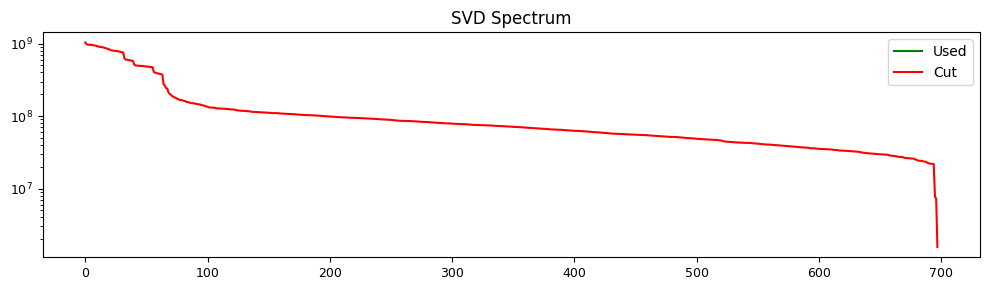

  LM inner 2: chi² 8.5681e+04 (previous 8.5681e+04), λ=0.01


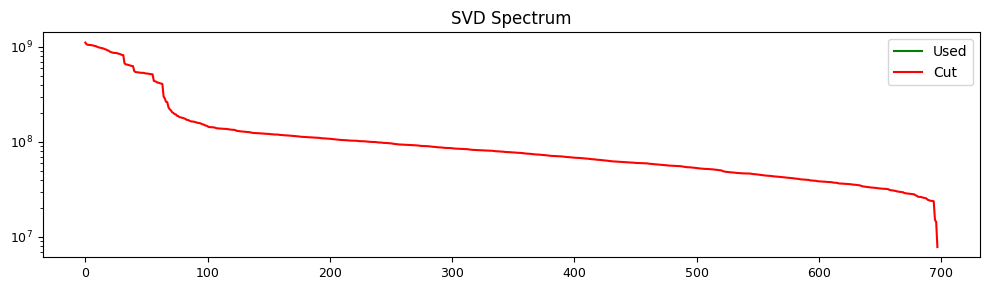

  LM inner 3: chi² 8.5681e+04 (previous 8.5681e+04), λ=0.1


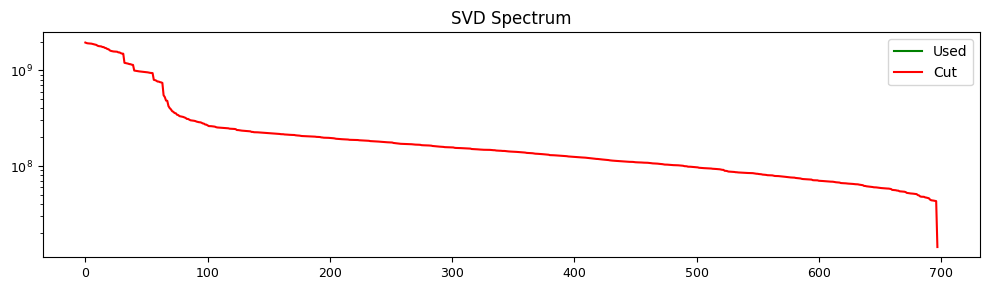

  LM inner 4: chi² 8.5681e+04 (previous 8.5681e+04), λ=1


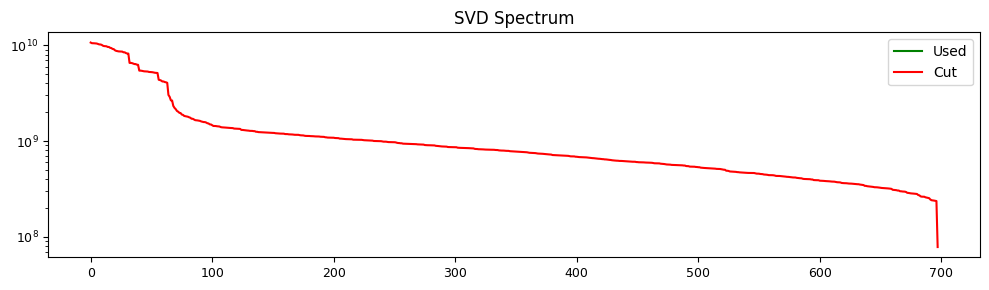

  LM inner 5: chi² 8.5681e+04 (previous 8.5681e+04), λ=10
  λ exceeded maximum; stop inner loop.
Chi² after correction: 8.5681e+04
LOCO LM completed! :).
[info] Saved fit_dict to output_all_err/fit_results_all_parameters.json


In [24]:
fit_cfg = FitInitConfig()
ring.disable_6d()
# --- define arguments ---
measured_orm = np.hstack((measured_orm, eta.reshape(-1, 1)))

nHorCOR = len(Corords[0])
nVerCOR = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter = 2

fit_list     = [
    #"quads",
    #'skew_quads' ,
    #'quads_tilt' ,
    "hbpm_gain",
    "vbpm_gain",
    "hcor_cal",
    "vcor_cal",
   # 'hbpm_coupling',
   # 'vbpm_coupling',
   # 'hcor_coupling',
   # 'vcor_coupling',
]


remove_coupling_ = True
includeDispersion = True
fixedpathlength = True
fixedmomentum = False
hor_dispersion_weight=5
ver_dispersion_weight=5

fit_results, fit_dict, ring_pyloco,fitted_orm,C_bpms_after = pyloco(
    ring,

    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=hor_dispersion_weight,
    ver_dispersion_weight=ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=rf_full_step,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=loco_options.individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method= 'user_input',
    svd_threshold = 1e-7,#64,
    cut_=0,
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength= fixedpathlength,
    fit_cfg=fit_cfg,
    fixedmomentum=fixedmomentum,

    # --- Jacopians files ---

    quad_jacobian_file="output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5",
    skew_jacobian_file=None,
    quads_tilt_jacobian_file=None,
    force_recompute=True
)

# --- save results ---
from pathlib import Path
save_fit_dict(fit_dict, Path("./output_all_err/fit_results_all_parameters"))
ring_pyloco.save('./output_all_err/ring_pyloco.mat', mat_key='ring')

[pyloco] Continuing from previous iteration set...
[pyloco] Building initial vector from previous stage...
[pyloco] Restoring previous values for hbpm_coupling...
[pyloco] Restoring previous values for vbpm_coupling...

==== Iteration 1/2 – LM ====
   No outliers in the data set.
Initial Chi²: 5.9532e+04


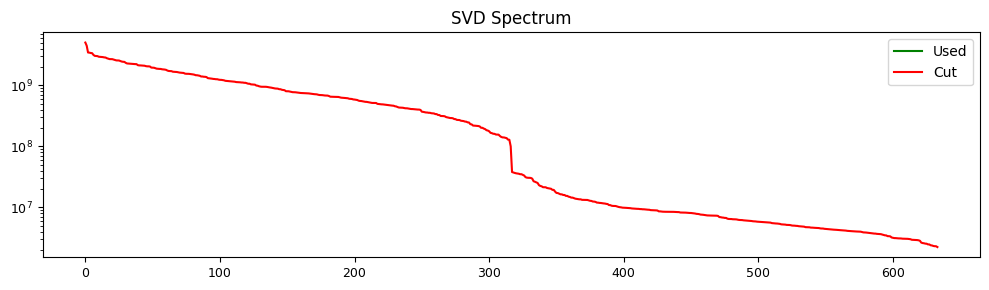

  LM inner 1: chi² 5.9532e+04 (previous 5.9532e+04), λ=0.001


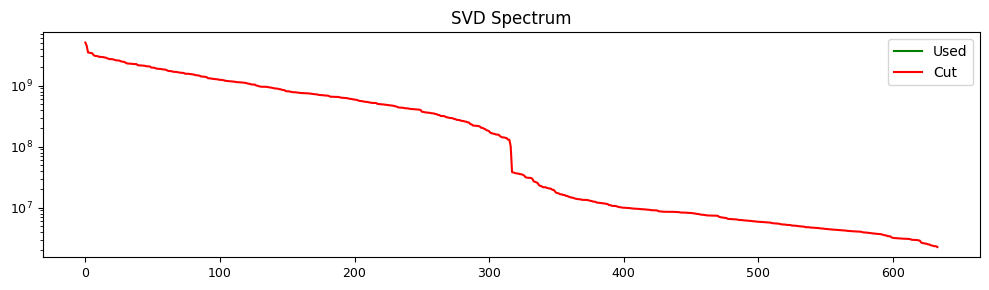

  LM inner 2: chi² 5.9532e+04 (previous 5.9532e+04), λ=0.01


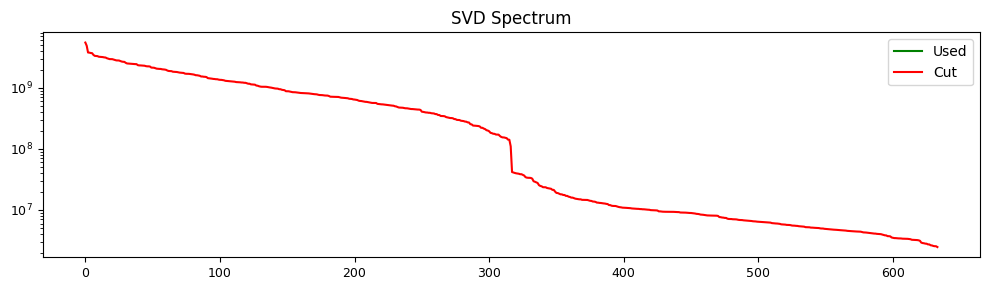

  LM inner 3: chi² 5.9532e+04 (previous 5.9532e+04), λ=0.1


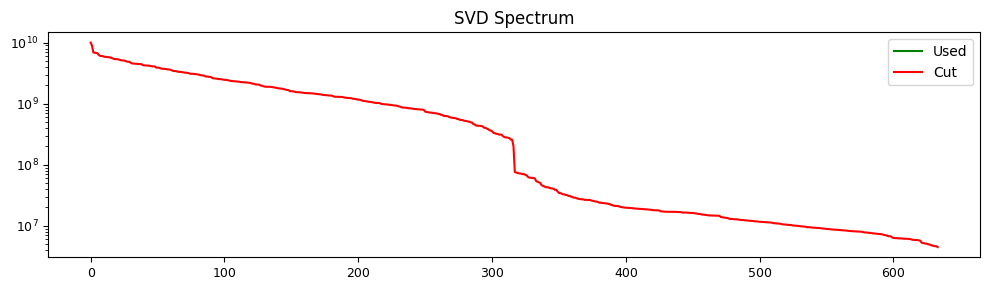

  LM inner 4: chi² 5.9532e+04 (previous 5.9532e+04), λ=1


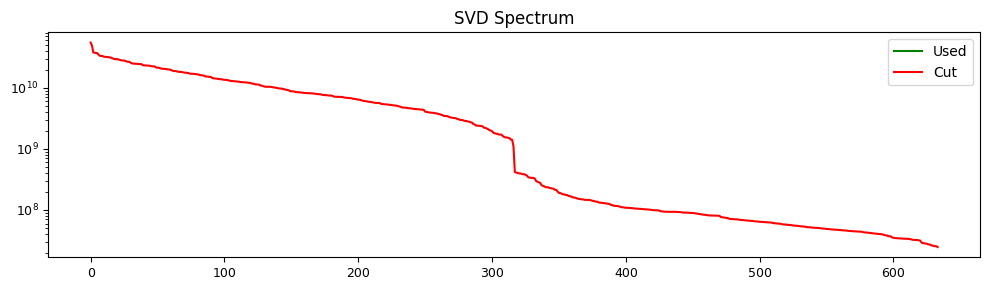

  LM inner 5: chi² 5.9532e+04 (previous 5.9532e+04), λ=10
  λ exceeded maximum; stop inner loop.
Chi² after correction: 5.9532e+04

==== Iteration 2/2 – LM ====
   No outliers in the data set.
Initial Chi²: 5.9532e+04


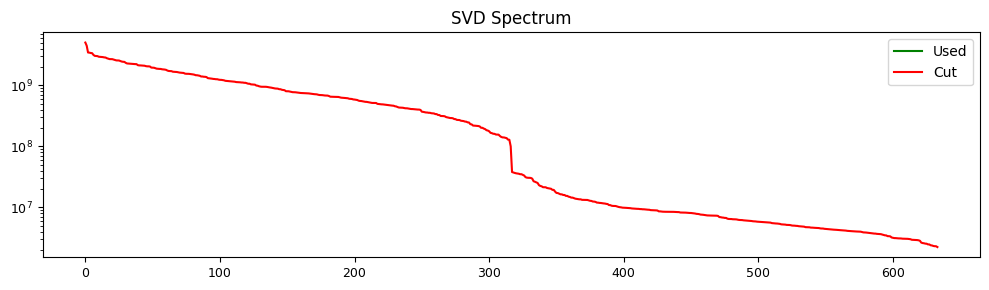

  LM inner 1: chi² 5.9532e+04 (previous 5.9532e+04), λ=0.001


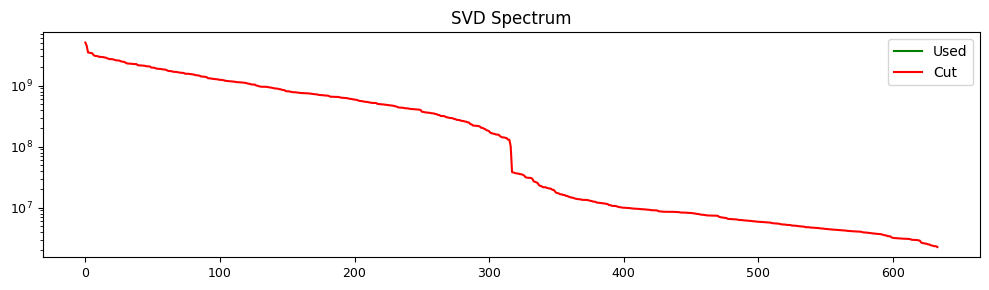

  LM inner 2: chi² 5.9532e+04 (previous 5.9532e+04), λ=0.01


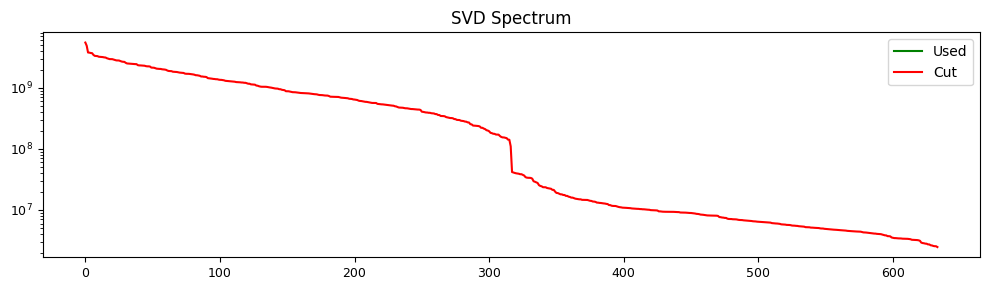

  LM inner 3: chi² 5.9532e+04 (previous 5.9532e+04), λ=0.1


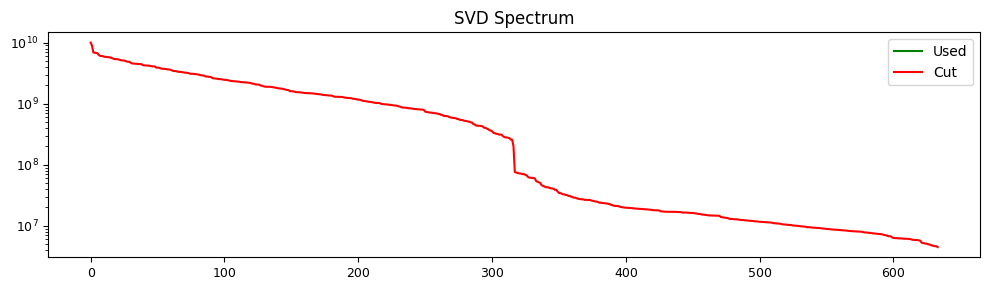

  LM inner 4: chi² 5.9532e+04 (previous 5.9532e+04), λ=1


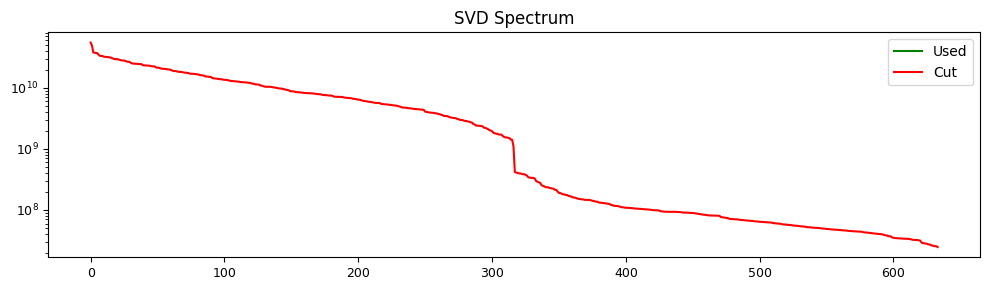

  LM inner 5: chi² 5.9532e+04 (previous 5.9532e+04), λ=10
  λ exceeded maximum; stop inner loop.
Chi² after correction: 5.9532e+04
LOCO LM completed! :).
[info] Saved fit_dict to output_all_err2/fit_results_all_parameters2.json


In [25]:
# In[2]:

fit_cfg = FitInitConfig()
ring.disable_6d()
# --- define arguments ---

nHorCOR = len(Corords[0])
nVerCOR = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter = 2


fit_list     = [
    #"quads",
    #'skew_quads' ,
    #'quads_tilt' ,
    #"hbpm_gain",
    #"vbpm_gain",
    #"hcor_cal",
    #"vcor_cal",
    'hbpm_coupling',
    'vbpm_coupling',
    #'hcor_coupling',
    #'vcor_coupling',
    #'delta_rf'
]

remove_coupling_ = False
includeDispersion = True

hor_dispersion_weight = 10
ver_dispersion_weight = 10

fit_results2, fit_dict2, ring_pyloco2 ,fitted_orm2, C_bpms_after2 = pyloco(
    ring_pyloco,

    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=hor_dispersion_weight,
    ver_dispersion_weight=ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=rf_full_step,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=loco_options.individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method= "user_input",
    svd_threshold = loco_options.svd_threshold,
    cut_= 0, #1280,
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength= fixedpathlength,
    fit_cfg=fit_cfg,
     fixedmomentum=fixedmomentum,

    # --- Jacopians files ---

    quad_jacobian_file="output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5",
    skew_jacobian_file=None,
    quads_tilt_jacobian_file=None,
    force_recompute=True,

    continue_from_previous=True,
    previous_fit_results=fit_results,
    previous_fit_dict=fit_dict,
    previous_ring=ring_pyloco
)

# --- save results ---
from pathlib import Path
save_fit_dict(fit_dict2, Path("./output_all_err2/fit_results_all_parameters2"))
ring_pyloco2.save('./output_all_err2/ring_pyloco2.mat', mat_key='ring')

[pyloco] Continuing from previous iteration set...
[pyloco] Building initial vector from previous stage...
[pyloco] Restoring previous values for quads...

==== Iteration 1/2 – LM ====
[Jacobian] File exists, but recomputing as requested (force_recompute=True).
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_26Jan_2026/output/quad_jacobian_logs2.txt'
[Jacobian] Saved normal-quadrupole Jacobian to output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5
   No outliers in the data set.
Initial Chi²: 8.4909e+04


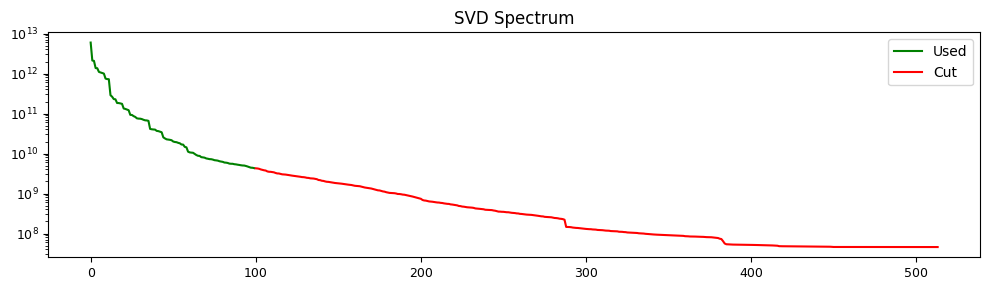

  LM inner 1: chi² 2.1616e+04 (previous 8.4909e+04), λ=0.001
Chi² after correction: 2.1616e+04

==== Iteration 2/2 – LM ====
[Jacobian] File exists, but recomputing as requested (force_recompute=True).
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_26Jan_2026/output/quad_jacobian_logs2.txt'
   No outliers in the data set.
Initial Chi²: 2.1616e+04


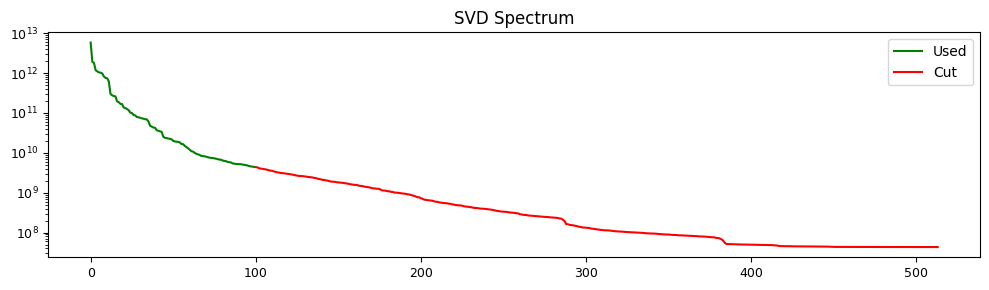

  LM inner 1: chi² 1.9574e+04 (previous 2.1616e+04), λ=0.001
Chi² after correction: 1.9574e+04
LOCO LM completed! :).
[info] Saved fit_dict to output_all_err3/fit_results_all_parameters3.json


In [46]:
# In[2]:

fit_cfg = FitInitConfig()
ring.disable_6d()
# --- define arguments ---

nHorCOR = len(Corords[0])
nVerCOR = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter = 2

fit_list     = [
    "quads",
    #'skew_quads' ,
    #'quads_tilt' ,
    #"hbpm_gain",
    #"vbpm_gain",
    #"hcor_cal",
    #"vcor_cal",
    #'hbpm_coupling',
    #'vbpm_coupling',
    #'hcor_coupling',
    #'vcor_coupling',
    #'delta_rf'
]

remove_coupling_ = True
includeDispersion = True
hor_dispersion_weight = 5
ver_dispersion_weight = 5

fit_results3, fit_dict3, ring_pyloco3,fitted_orm3, C_bpms_after3 = pyloco(
    ring_pyloco2,

    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=hor_dispersion_weight,
    ver_dispersion_weight=ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=rf_full_step,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=loco_options.individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method="user_input",
    svd_threshold = loco_options.svd_threshold,
    cut_=100 ,#100, #64
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength= fixedpathlength,
    fit_cfg=fit_cfg,
     fixedmomentum=fixedmomentum,
    # --- Jacopians files ---

    quad_jacobian_file="output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5",
    skew_jacobian_file=None,
    quads_tilt_jacobian_file=None,
    force_recompute=True,

    continue_from_previous=True,
    previous_fit_results=fit_results2,
    previous_fit_dict=fit_dict2,
    previous_ring=ring_pyloco2
)

# --- save results ---
from pathlib import Path
save_fit_dict(fit_dict3, Path("./output_all_err3/fit_results_all_parameters3"))
ring_pyloco3.save('./output_all_err3/ring_pyloco3.mat', mat_key='ring')

[pyloco] Continuing from previous iteration set...
[pyloco] Building initial vector from previous stage...
[pyloco] Restoring previous values for skew_quads...
[pyloco] Restoring previous values for hbpm_coupling...
[pyloco] Restoring previous values for vbpm_coupling...

==== Iteration 1/2 – LM ====
[Jacobian] File exists, but recomputing as requested (force_recompute=True).
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_26Jan_2026/output/skew_jacobian_logs.txt'
[Jacobian] Saved skew-quadrupole Jacobian to output/jacobians/skew/J_skew_iter1_0.0001urad_200Hz.h5
   std(Model-Measurement) = 0.028343 mm (with outliers)
   13 outliers removed out of 41210 points (> 10 sigma) (13 first test + 0 second test).
Initial Chi²: 2.6689e+04


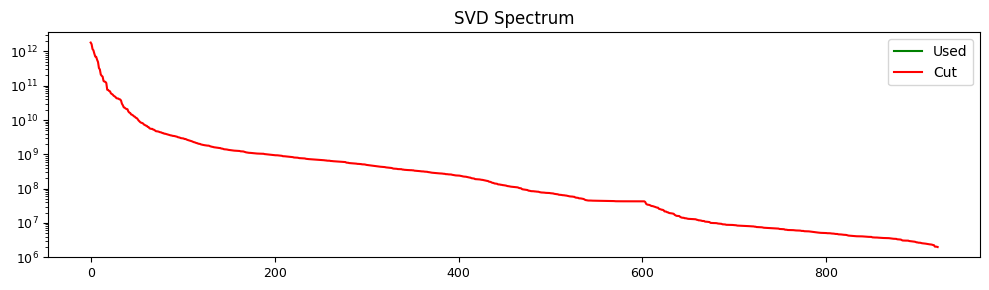

  LM inner 1: chi² 2.6689e+04 (previous 2.6689e+04), λ=0.001


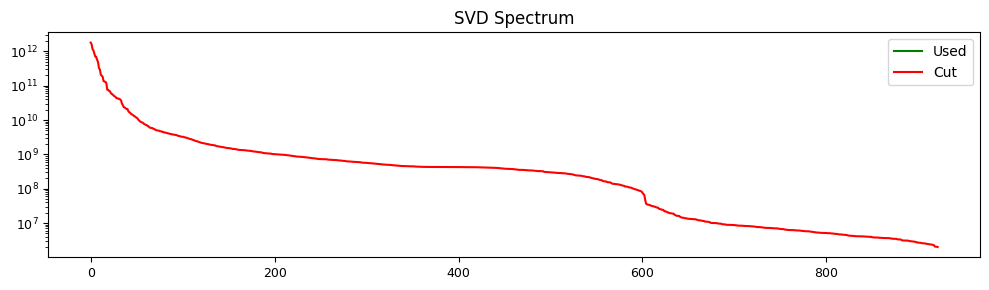

  LM inner 2: chi² 2.6689e+04 (previous 2.6689e+04), λ=0.01


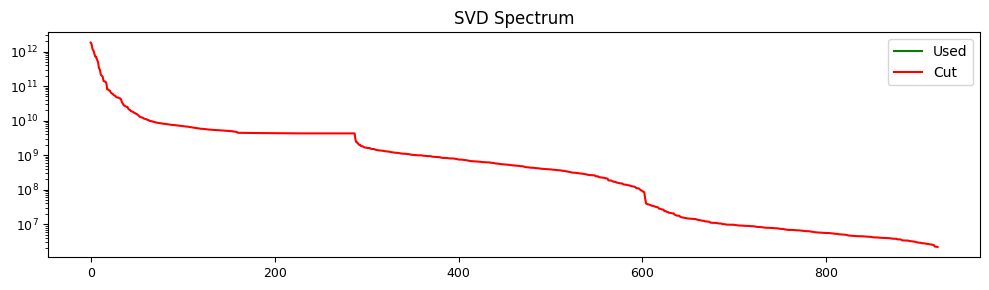

  LM inner 3: chi² 2.6689e+04 (previous 2.6689e+04), λ=0.1


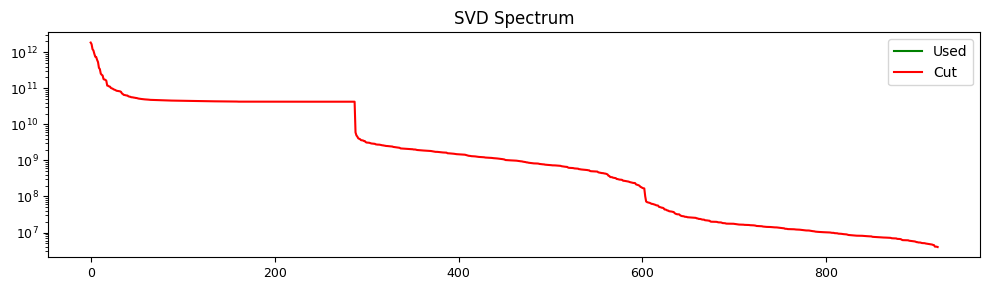

  LM inner 4: chi² 2.6689e+04 (previous 2.6689e+04), λ=1


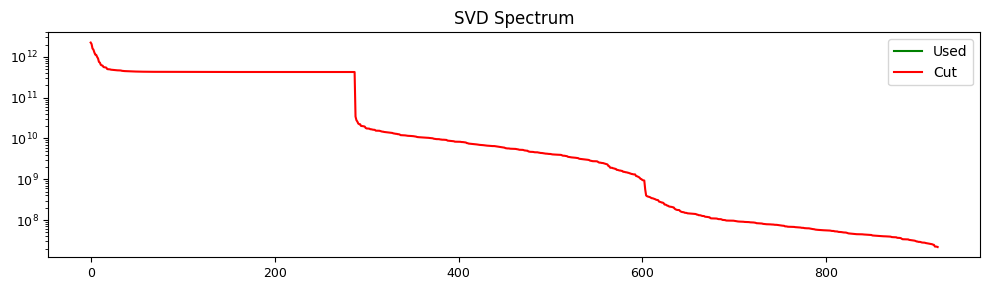

  LM inner 5: chi² 2.6689e+04 (previous 2.6689e+04), λ=10
  λ exceeded maximum; stop inner loop.
Chi² after correction: 2.6689e+04

==== Iteration 2/2 – LM ====
[Jacobian] Computing skew-quadrupole Jacobian (iteration 2)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS/EBS_MDT_26Jan_2026/output/skew_jacobian_logs.txt'
   std(Model-Measurement) = 0.028343 mm (with outliers)
   13 outliers removed out of 41210 points (> 10 sigma) (13 first test + 0 second test).
Initial Chi²: 2.6689e+04


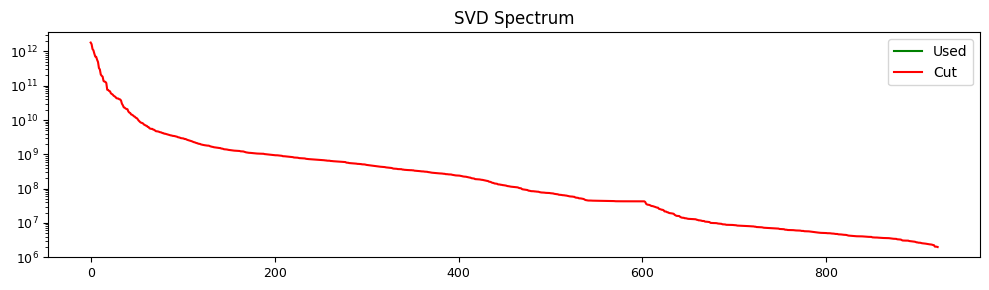

  LM inner 1: chi² 2.6689e+04 (previous 2.6689e+04), λ=0.001


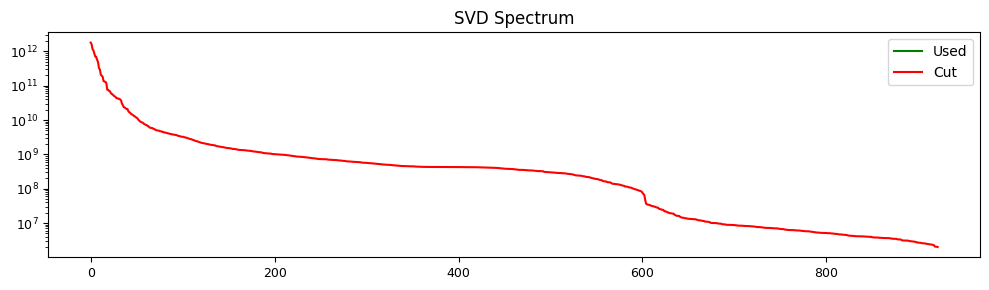

  LM inner 2: chi² 2.6689e+04 (previous 2.6689e+04), λ=0.01


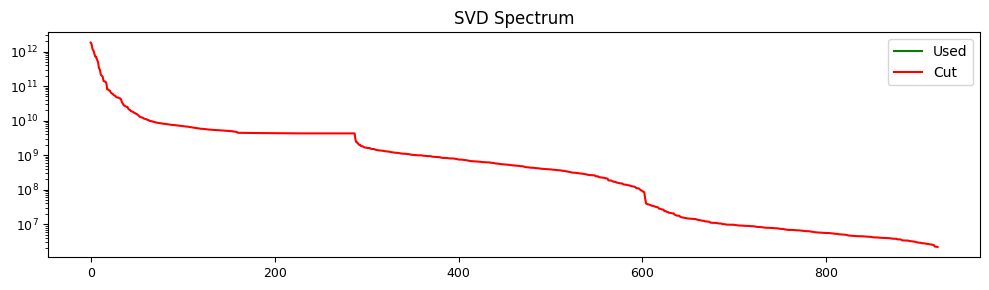

  LM inner 3: chi² 2.6689e+04 (previous 2.6689e+04), λ=0.1


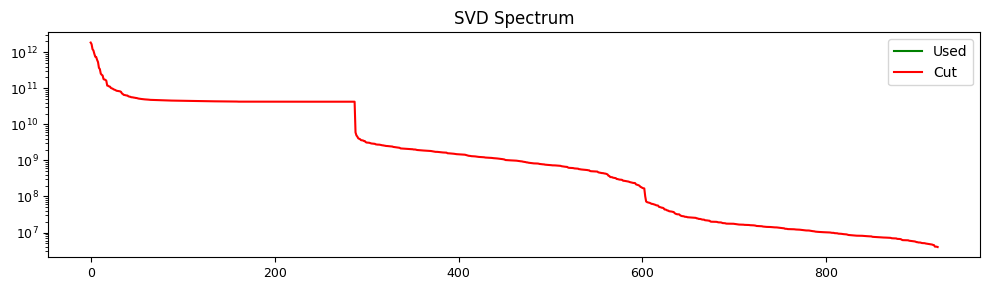

  LM inner 4: chi² 2.6689e+04 (previous 2.6689e+04), λ=1


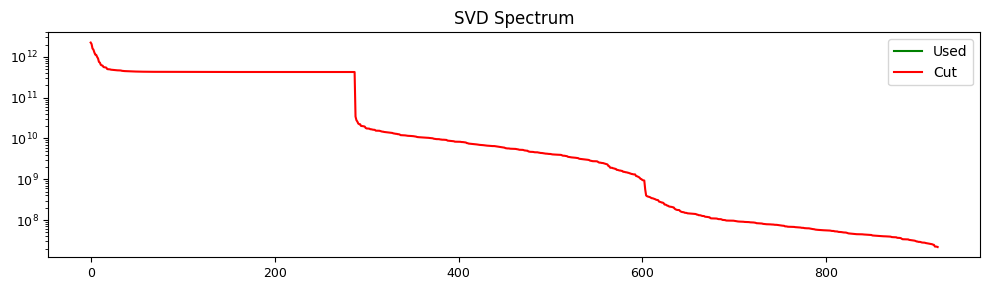

  LM inner 5: chi² 2.6689e+04 (previous 2.6689e+04), λ=10
  λ exceeded maximum; stop inner loop.
Chi² after correction: 2.6689e+04
LOCO LM completed! :).
[info] Saved fit_dict to output_all_err4/fit_results_all_parameters4.json


In [47]:
# In[2]:

fit_cfg = FitInitConfig()
ring.disable_6d()
# --- define arguments ---

nHorCOR = len(Corords[0])
nVerCOR = len(Corords[1])
nHBPM = nVBPM = len(used_bpms_ords)
nIter = 2


fit_list     = [
    #"quads",
    'skew_quads' ,
    #'quads_tilt' ,
    #"hbpm_gain",
    #"vbpm_gain",
    #"hcor_cal",
    #"vcor_cal",
    'hbpm_coupling',
    'vbpm_coupling',
    #'hcor_coupling',
    #'vcor_coupling',
    #'delta_rf'
]

remove_coupling_ = False
includeDispersion = True
hor_dispersion_weight = 5
ver_dispersion_weight = 5

fit_results4, fit_dict4, ring_pyloco4,fitted_orm4, C_bpms_after4 = pyloco(
    ring_pyloco3,

    # --- general control ---
    algorithm=loco_options.algorithm,
    nIter= nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=skew_ord,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=quad_indices,
    inetial_fit_parameters=None,

    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=includeDispersion,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=hor_dispersion_weight,
    ver_dispersion_weight=ver_dispersion_weight,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=rf_full_step,
    Frequency=fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=loco_options.individuals,
    remove_coupling_= remove_coupling_,

    # --- outliers & normalization ---
    outlier_rejection=loco_options.outlier_rejection,
    sigma_outlier=loco_options.sigma_outlier,
    apply_normalization=loco_options.apply_normalization,
    normalization_mode=loco_options.normalization_mode,

    # --- SVD selection ---
    svd_selection_method="user_input",
    svd_threshold = loco_options.svd_threshold,
    cut_= 0, #60,
    show_svd_plot=loco_options.show_svd_plot,

    # --- LM options ---
    nLMIter=loco_options.nLMIter,
    Starting_Lambda=loco_options.Starting_Lambda,
    max_lm_lambda=loco_options.max_lm_lambda,
    scaled=loco_options.scaled,

    # --- more options ---
    plot_fit_parameters=loco_options.plot_fit_parameters,
    auto_correct_delta=loco_options.auto_correct_delta,
    fixedpathlength= fixedpathlength,
    fit_cfg=fit_cfg,
     fixedmomentum=fixedmomentum,
    # --- Jacopians files ---

    quad_jacobian_file="output_all_err/jacobians/quads/J_quads_iter1_0.0001urad_200Hz.h5",
    skew_jacobian_file=None,
    quads_tilt_jacobian_file=None,
    force_recompute=True,

    continue_from_previous=True,
    previous_fit_results=fit_results3,
    previous_fit_dict=fit_dict3,
    previous_ring=ring_pyloco3
)

# --- save results ---
from pathlib import Path
save_fit_dict(fit_dict4, Path("./output_all_err4/fit_results_all_parameters4"))
ring_pyloco4.save('./output_all_err4/ring_pyloco4.mat', mat_key='ring')

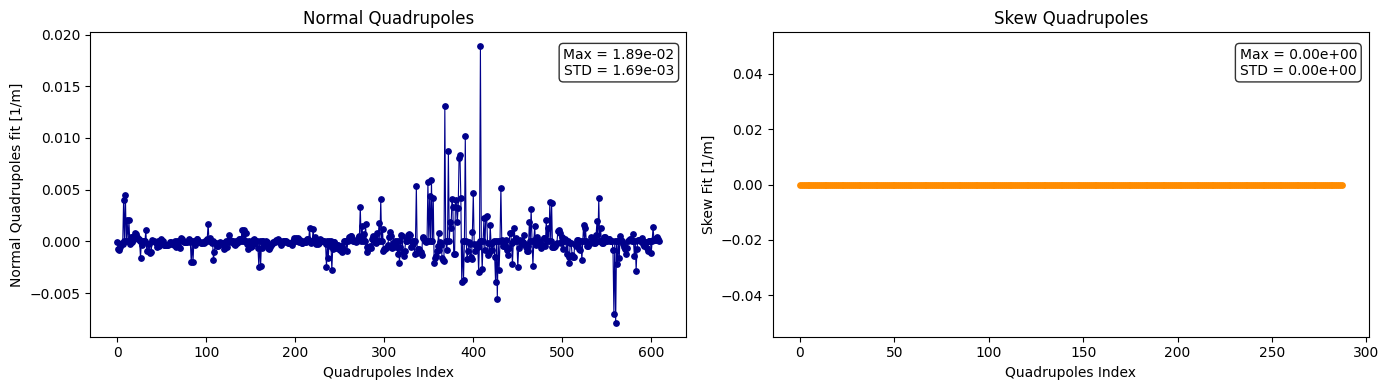

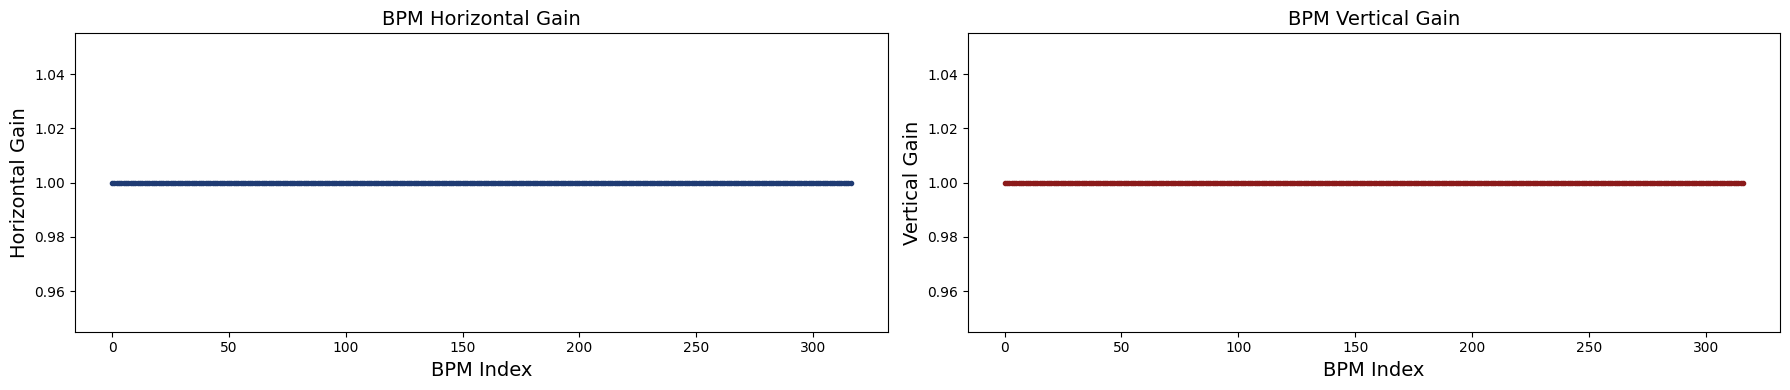

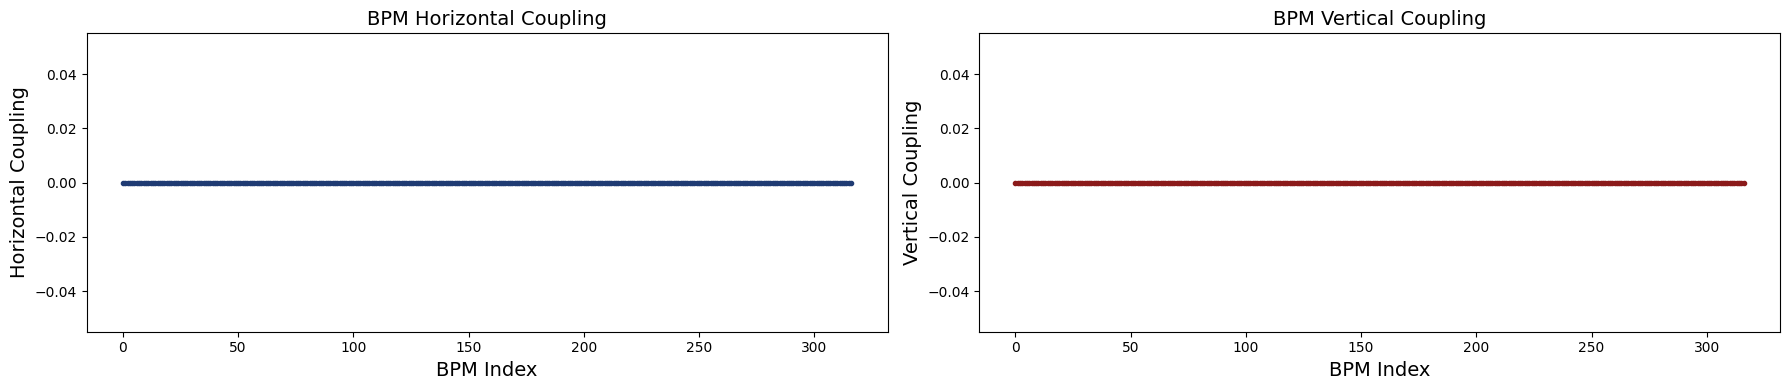

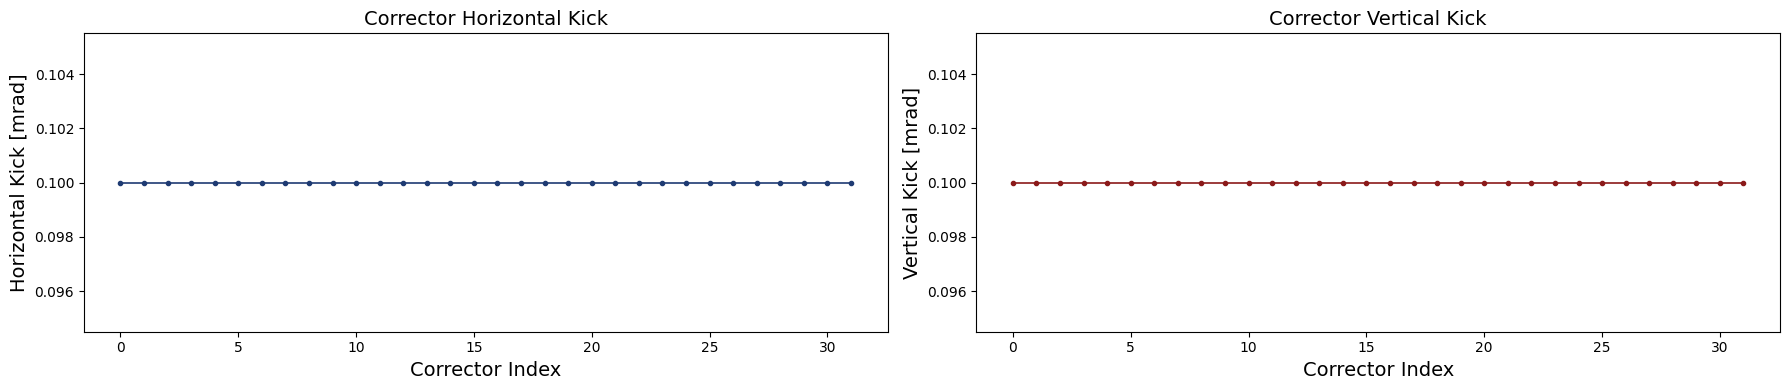

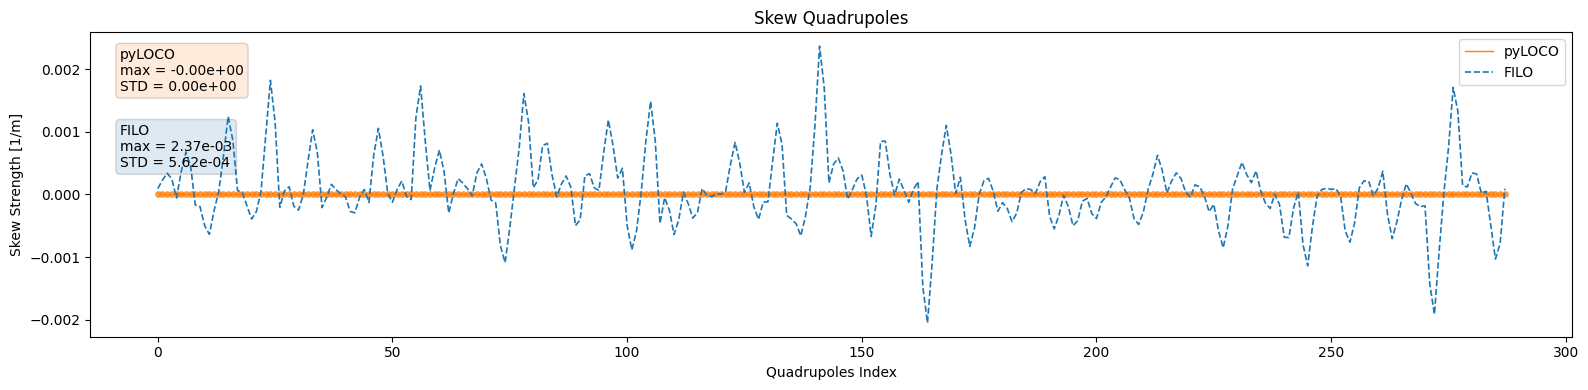

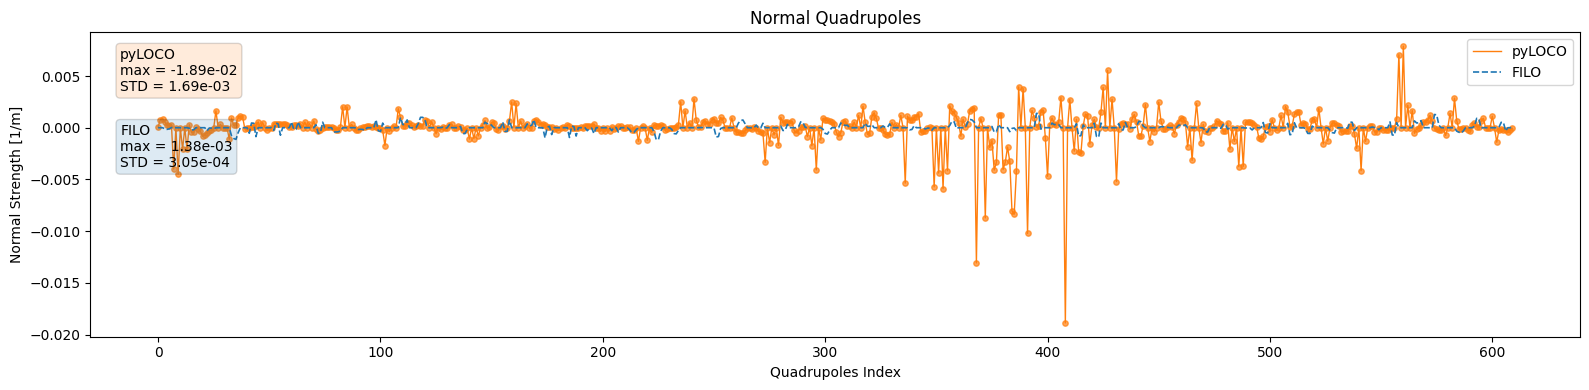

Saved to output/quad_skew_deltas_lengths_C1.json


In [48]:
import matplotlib.pyplot as plt

hbpm_gain = get_fit_param_block(fit_dict4, "hbpm_gain")
vbpm_gain = get_fit_param_block(fit_dict4, "vbpm_gain")

hbpm_coupling = get_fit_param_block(fit_dict4, "hbpm_coupling")
vbpm_coupling = get_fit_param_block(fit_dict4, "vbpm_coupling")

skew_quads = get_fit_param_block(fit_dict4, "skew_quads")
quads = get_fit_param_block(fit_dict4, "quads")

hcor_cal = get_fit_param_block(fit_dict4, "hcor_cal")
vcor_cal = get_fit_param_block(fit_dict4, "vcor_cal")


# --- Compute delta_q ---
delta_q = np.asarray(
    [(quads[i] - ring[quad_indices[i]].PolynomB[1]) * ring[quad_indices[i]].Length
     for i in range(len(quad_indices))],
    dtype=float
)


# --- Compute delta_skew ---
delta_skew = np.asarray(
    [(skew_quads[i] - ring[skew_ord[i]].PolynomA[1]) * ring[skew_ord[i]].Length
     for i in range(len(skew_ord))],
    dtype=float
)
x_s = range(len(delta_skew))


ring.reduce()
all_q_ind = at.get_refpts(ring, at.elements.Quadrupole)
DQ0 = at.get_refpts(ring, "DQ*")
removed_dq_ind  = [796, 1751, 2994]
DQ = np.delete(DQ0, np.where(np.isin(DQ0, removed_dq_ind)))
q_dq = np.append(DQ, all_q_ind)
q_dq = sorted(q_dq)
PINHOLE = at.get_refpts(ring, "PINHOLE*")
index_map = {q: i for i, q in enumerate(q_dq)}
q_dq_strength = np.zeros(len(q_dq))
for k, q in enumerate(quad_indices):
    i = index_map[q]        # correct index in full list
    q_dq_strength[i] = delta_q[k]

x_q = range(len(q_dq_strength))

fig, axes = plt.subplots(
    ncols=2,
    figsize=(14, 4),
    sharey=False
)

# Normal quadrupoles

axes[0].scatter(x_q, q_dq_strength, s=15, color='darkblue')
axes[0].plot(x_q, q_dq_strength, linewidth=0.8, color='darkblue')
axes[0].set_xlabel("Quadrupoles Index")
axes[0].set_ylabel("Normal Quadrupoles fit [1/m]")
axes[0].set_title("Normal Quadrupoles")

text_q = (

    f"Max = {q_dq_strength.max():.2e}\n"
    f"STD = {np.std(q_dq_strength):.2e}"
)
axes[0].text(
    0.98, 0.95, text_q,
    transform=axes[0].transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# Skew quadrupoles

axes[1].scatter(x_s, delta_skew, s=15, color='darkorange')
axes[1].plot(x_s, delta_skew, linewidth=0.8, color='darkorange')
axes[1].set_xlabel("Quadrupoles Index")
axes[1].set_ylabel("Skew Fit [1/m]")
axes[1].set_title("Skew Quadrupoles")

text_s = (

    f"Max = {delta_skew.max():.2e}\n"
    f"STD = {np.std(delta_skew):.2e}"
)
axes[1].text(
    0.98, 0.95, text_s,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()



import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey=False)

axes[0].plot(
    hbpm_gain,
    marker="o",
    linestyle="-",
    markersize=3,
    linewidth=1.2,
    color="#1f3b73"
)
axes[0].set_title("BPM Horizontal Gain", fontsize=14)
axes[0].set_xlabel("BPM Index", fontsize=14)
axes[0].set_ylabel("Horizontal Gain", fontsize=14)

axes[1].plot(
    vbpm_gain,
    marker="o",
    linestyle="-",
    markersize=3,
    linewidth=1.2,
    color="#8b1a1a"
)
axes[1].set_title("BPM Vertical Gain", fontsize=14)
axes[1].set_xlabel("BPM Index", fontsize=14)
axes[1].set_ylabel("Vertical Gain", fontsize=14)

plt.tight_layout()
plt.show()




fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey=False)

axes[0].plot(
    hbpm_coupling,
    marker="o",
    linestyle="-",
    markersize=3,
    linewidth=1.2,
    color="#1f3b73"
)
axes[0].set_title("BPM Horizontal Coupling", fontsize=14)
axes[0].set_xlabel("BPM Index", fontsize=14)
axes[0].set_ylabel("Horizontal Coupling", fontsize=14)

axes[1].plot(
    vbpm_coupling,
    marker="o",
    linestyle="-",
    markersize=3,
    linewidth=1.2,
    color="#8b1a1a"
)
axes[1].set_title("BPM Vertical Coupling", fontsize=14)
axes[1].set_xlabel("BPM Index", fontsize=14)
axes[1].set_ylabel("Vertical Coupling", fontsize=14)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey=False)

axes[0].plot(
    hcor_cal * 1000,
    marker="o",
    linestyle="-",
    markersize=3,
    linewidth=1.2,
    color="#1f3b73"
)
axes[0].set_title("Corrector Horizontal Kick", fontsize=14)
axes[0].set_xlabel("Corrector Index", fontsize=14)
axes[0].set_ylabel("Horizontal Kick [mrad]", fontsize=14)

axes[1].plot(
    vcor_cal * 1000,
    marker="o",
    linestyle="-",
    markersize=3,
    linewidth=1.2,
    color="#8b1a1a"
)
axes[1].set_title("Corrector Vertical Kick", fontsize=14)
axes[1].set_xlabel("Corrector Index", fontsize=14)
axes[1].set_ylabel("Vertical Kick [mrad]", fontsize=14)

plt.tight_layout()
plt.show()


KLs0_sl = np.load('KLs0_sl.npy')
KLq0_sl = np.load('KLn0_sl.npy')
fig, ax = plt.subplots(
    ncols=1,
    figsize=(16, 4),
    sharey=False
)

# --- Data ---
ax.scatter(x_s, -delta_skew, s=15, color='tab:orange', alpha=0.7)
ax.plot(x_s, -delta_skew, linewidth=1.0, color='tab:orange', label='pyLOCO')

ax.plot(x_s, KLs0_sl, linewidth=1.2, color='tab:blue',
        linestyle='--', label='FILO')

# --- Labels ---
ax.set_xlabel("Quadrupoles Index")
ax.set_ylabel("Skew Strength [1/m]")
ax.set_title("Skew Quadrupoles")

# --- Statistics boxes ---
text_fit = (
    f"pyLOCO\n"
    f"max = {-delta_skew.max():.2e}\n"
    f"STD = {np.std(-delta_skew):.2e}"
)

text_model = (
    f"FILO\n"
    f"max = {KLs0_sl.max():.2e}\n"
    f"STD = {np.std(KLs0_sl):.2e}"
)

ax.text(
    0.02, 0.95, text_fit,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor='tab:orange', alpha=0.15)
)

ax.text(
    0.02, 0.70, text_model,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor='tab:blue', alpha=0.15)
)

ax.legend()
plt.tight_layout()
plt.show()



KLs0_sl = np.load('KLs0_sl.npy')
KLq0_sl = np.load('KLn0_sl.npy')

ring.reduce()
all_q_ind = at.get_refpts(ring, at.elements.Quadrupole)
DQ0 = at.get_refpts(ring, "DQ*")
removed_dq_ind  = [796, 1751, 2994]
DQ = np.delete(DQ0, np.where(np.isin(DQ0, removed_dq_ind)))
q_dq = np.append(DQ, all_q_ind)
q_dq = sorted(q_dq)
PINHOLE = at.get_refpts(ring, "PINHOLE*")
index_map = {q: i for i, q in enumerate(q_dq)}
q_dq_strength = np.zeros(len(q_dq))
for k, q in enumerate(quad_indices):
    i = index_map[q]        # correct index in full list
    q_dq_strength[i] = delta_q[k]

fig, ax = plt.subplots(
    ncols=1,
    figsize=(16, 4),
    sharey=False
)
x_q = range(len(q_dq_strength))
# --- Data ---
ax.scatter(x_q, -q_dq_strength, s=15, color='tab:orange', alpha=0.7)
ax.plot(x_q, -q_dq_strength, linewidth=1.0, color='tab:orange', label='pyLOCO')

ax.plot(x_q, KLq0_sl, linewidth=1.2, color='tab:blue',
        linestyle='--', label='FILO')

# --- Labels ---
ax.set_xlabel("Quadrupoles Index")
ax.set_ylabel("Normal Strength [1/m]")
ax.set_title("Normal Quadrupoles")

# --- Statistics boxes ---
text_fit = (
    f"pyLOCO\n"
    f"max = {-q_dq_strength.max():.2e}\n"
    f"STD = {np.std(-q_dq_strength):.2e}"
)

text_model = (
    f"FILO\n"
    f"max = {KLq0_sl.max():.2e}\n"
    f"STD = {np.std(KLq0_sl):.2e}"
)

ax.text(
    0.02, 0.95, text_fit,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor='tab:orange', alpha=0.15)
)

ax.text(
    0.02, 0.70, text_model,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor='tab:blue', alpha=0.15)
)

ax.legend()
plt.tight_layout()
plt.show()


import json
from pathlib import Path


length_quad = np.asarray(
    [ring[quad_indices[i]].Length for i in range(len(quad_indices))],
    dtype=float
).ravel()

length_skew = np.asarray(
    [ring[skew_ord[i]].Length for i in range(len(skew_ord))],
    dtype=float
).ravel()

delta_dict = {int(indx): delta for indx, delta in zip(quad_indices, -delta_q)}
deltas_dict = {int(indx): delta for indx, delta in zip(skew_ord, -delta_skew)}

length_dict = {int(indx): length for indx, length in zip(quad_indices, length_quad)}
lengths_dict = {int(indx): length for indx, length in zip(skew_ord, length_skew)}

data_all = {
    "normal_quads": {
        "delta": delta_dict,
        "length": length_dict
    },
    "skew_quads": {
        "delta": deltas_dict,
        "length": lengths_dict
    }
}

output_path = Path("./output")
output_path.mkdir(parents=True, exist_ok=True)

with open(output_path / "quad_skew_deltas_lengths_C1.json", "w") as f:
    json.dump(data_all, f, indent=4)

print(f"Saved to {output_path / 'quad_skew_deltas_lengths_C1.json'}")

In [49]:
6e-2

0.06

[]

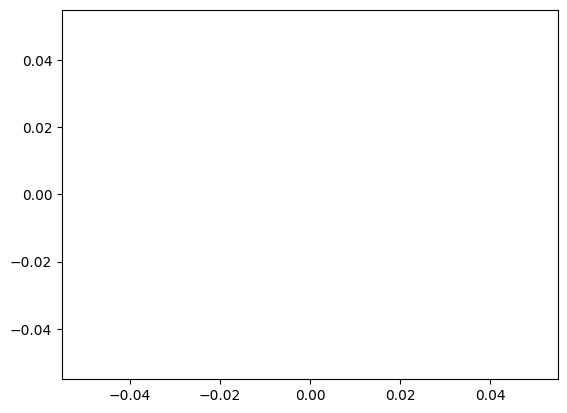

In [50]:
plt.plot()

Lattice tune after loco : [0.17913922 0.37630743 0.00368175]
Lattice Chroma after loco : [9.13042590e+00 5.95285563e+00 4.31949273e-03]
Lattice Hor emittance after loco : 284.6931187340372 pm
Lattice Ver emittance after loco : 0.0 pm


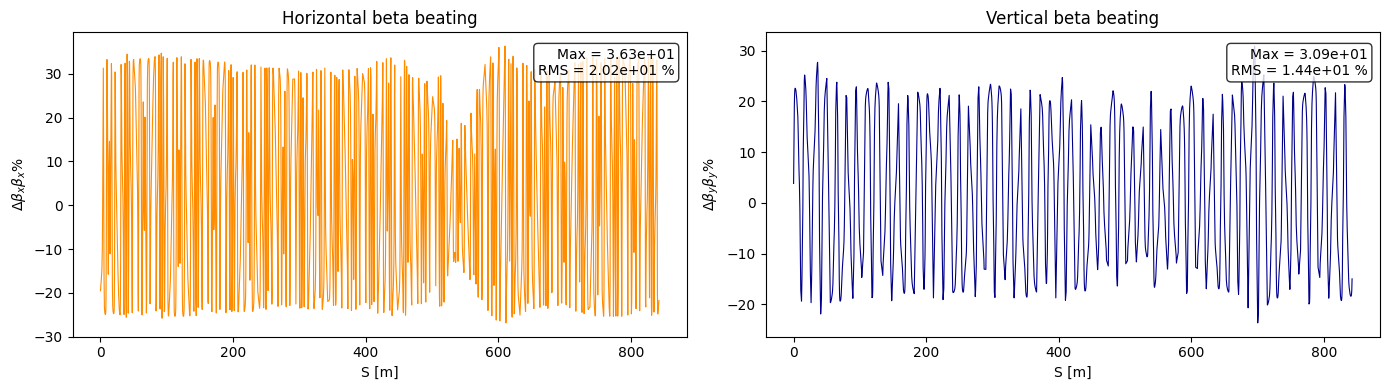

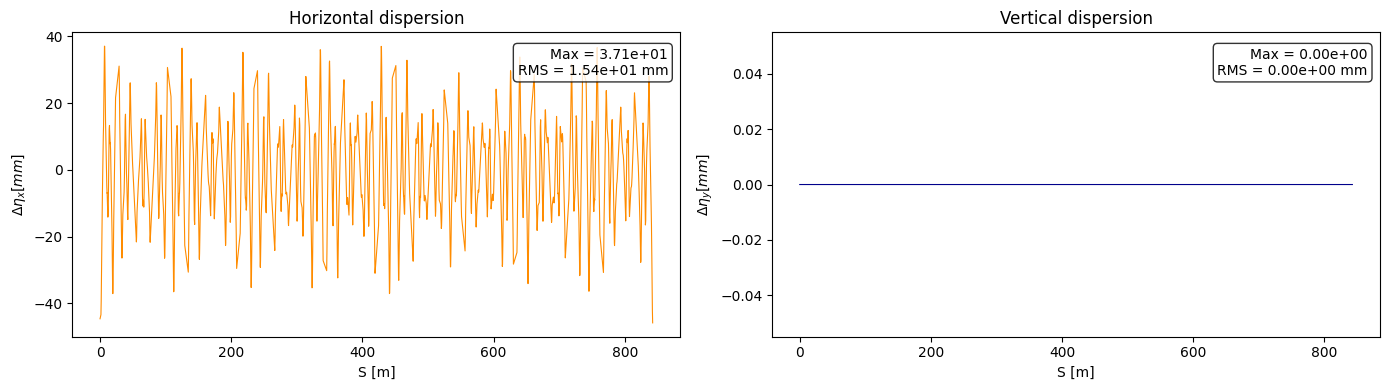

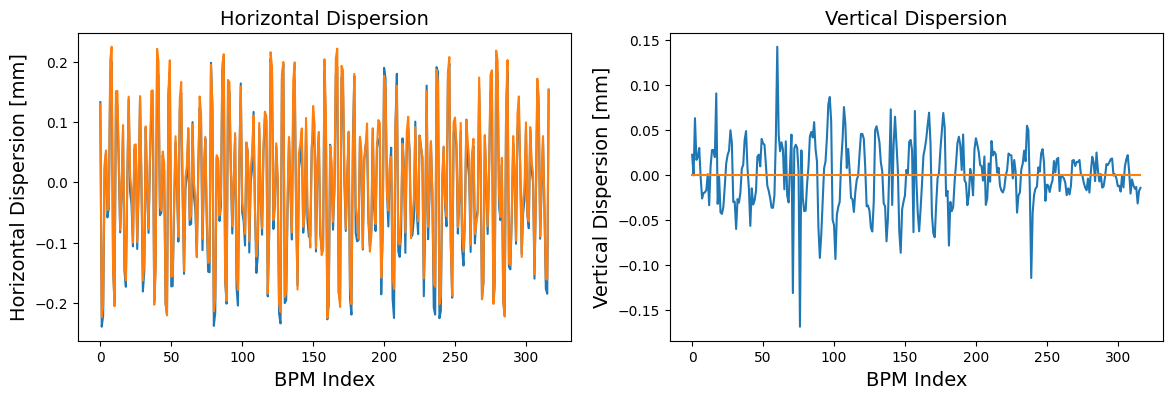

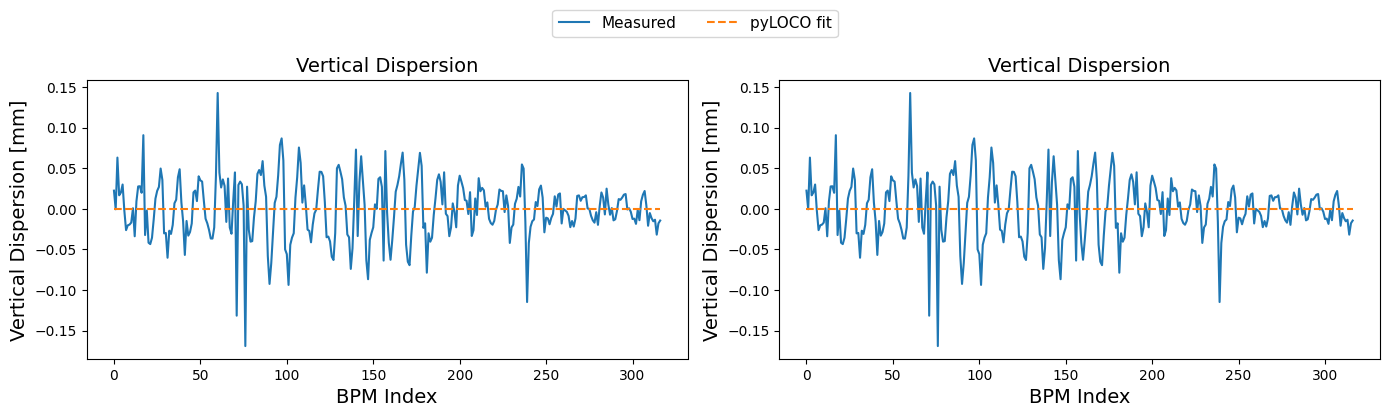

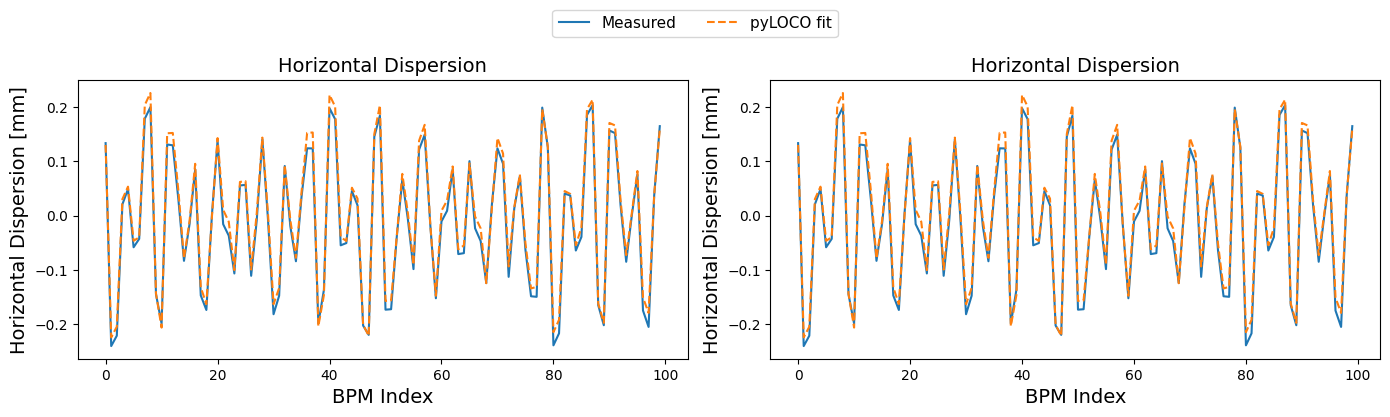

<Figure size 640x480 with 0 Axes>

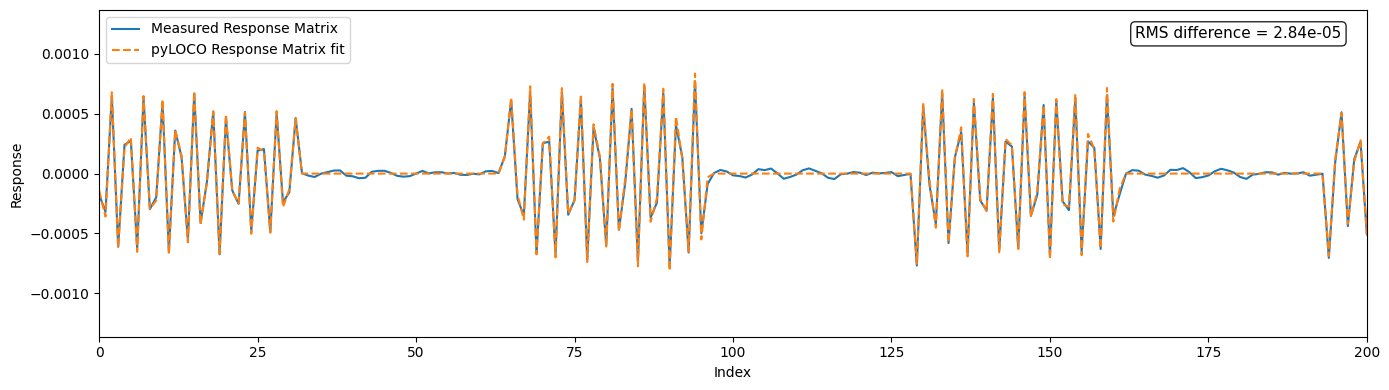

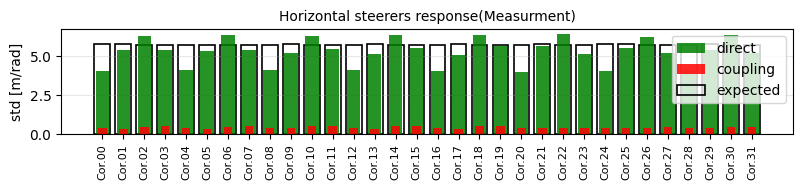

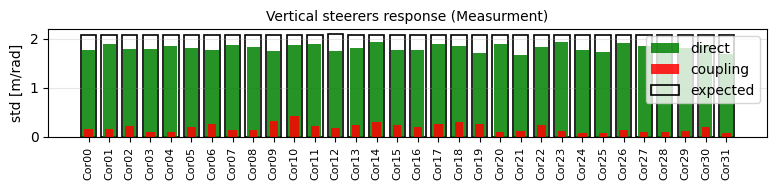

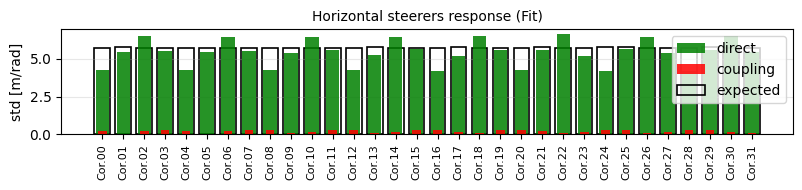

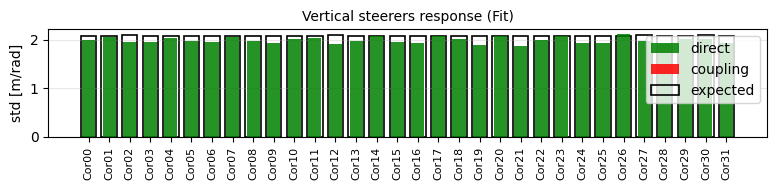

In [51]:
import at
import h5py
import pySC
import logging
import numpy as np
from pySC.apps import measure_ORM
from pySC.apps.interface import pySCOrbitInterface
from pySC.tuning.response_measurements import measure_RFFrequencyOrbitResponse

#logging.getLogger('pySC.apps.response').setLevel(logging.DEBUG)
logger = logging.getLogger(__name__)



ring_pyloco4.enable_6d()
print('Lattice tune after loco :' , at.get_tune(ring_pyloco4))
print('Lattice Chroma after loco :' , at.get_chrom(ring_pyloco4))

emit0, _, _ = ring_pyloco4.ohmi_envelope()                                                        # [m·rad]
emittance_h = emit0['emitXY'][0]
emittance_v = emit0['emitXY'][1]
print('Lattice Hor emittance after loco :' , float(emittance_h * 1e12), 'pm')
print('Lattice Ver emittance after loco :' , float(emittance_v * 1e12), 'pm')
ring_pyloco4.disable_6d()
ring = at.load_lattice('betamodel.mat', use='betamodel')
ring.disable_6d()
elements_ind = at.get_refpts(ring, "*")
_, _, twiss = at.get_optics(ring, elements_ind)
_, _, twiss_err = at.get_optics(ring_pyloco4, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0] - twiss.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1] - twiss.beta[:, 1]) / twiss.beta[:, 1]
dx = (twiss_err.dispersion[:, 0] - twiss.dispersion[:, 0]) #/ twiss.beta[:, 0]
dy = (twiss_err.dispersion[:, 2] - twiss.dispersion[:, 2]) #/ twiss.beta[:, 1]

plot_beta(s_pos, bx, by)
plot_eta(s_pos, dx, dy)

from pyloco_config import fixed_parameters
from pyloco_config import RMConfig as config, _cfg_get
import at
from pyLOCO.analysis import calculate_dispersion
bpm_ords = at.get_refpts(ring, at.elements.Monitor)
RFAttr = _cfg_get(config, "RFAttr", "Frequency")
dis_0= calculate_dispersion(ring, fixed_parameters, used_bpms_ords, calculator = 'Linear', rfStep = 200, RFAttr = RFAttr)
fit_eta_x0 =  dis_0[:len(used_bpms_ords)]
fit_eta_y0 = dis_0[len(used_bpms_ords) :]
dis_fit = calculate_dispersion(ring_pyloco4, fixed_parameters, used_bpms_ords, calculator = 'Linear', rfStep = 200, RFAttr = RFAttr)
fit_eta_x =  dis_fit[:len(used_bpms_ords)]
fit_eta_y = dis_fit[len(used_bpms_ords) :]
ORM_fit = fitted_orm4#np.load('last_orm_model.npy')
#measured_orm = np.hstack((measured_orm, eta.reshape(-1, 1)))

fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharex=False)

# Horizontal dispersion
axes[0].plot((measured_eta_x - fit_eta_x0) * 1000, label='Measured')
axes[0].plot((fit_eta_x - fit_eta_x0) * 1000, label='pyLOCO fit')
axes[0].set_title("Horizontal Dispersion", fontsize=14)
axes[0].set_xlabel("BPM Index", fontsize=14)
axes[0].set_ylabel("Horizontal Dispersion [mm]", fontsize=14)

# Vertical dispersion
axes[1].plot((measured_eta_y -fit_eta_y0) * 1000, label='Measured')
axes[1].plot((fit_eta_y -fit_eta_y0)* 1000, label='pyLOCO fit')
axes[1].set_title("Vertical Dispersion", fontsize=14)
axes[1].set_xlabel("BPM Index", fontsize=14)
axes[1].set_ylabel("Vertical Dispersion [mm]", fontsize=14)


###### Fit of calibration errors


dis_fit_2  = dis_fit @ C_bpms_after4
fit_eta_x2 = dis_fit_2[:len(used_bpms_ords)]
fit_eta_y2 = dis_fit_2[len(used_bpms_ords):]


fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharex=False)

# Horizontal dispersion
axes[0].plot((measured_eta_y - fit_eta_y0) * 1000, label='Measured')
axes[0].plot((fit_eta_y-fit_eta_y0) * 1000, '--', label='pyLOCO fit')
axes[0].set_title("Vertical Dispersion", fontsize=14)
axes[0].set_xlabel("BPM Index", fontsize=14)
axes[0].set_ylabel("Vertical Dispersion [mm]", fontsize=14)

# Vertical dispersion
axes[1].plot((measured_eta_y -fit_eta_y0)* 1000, label='Measured')
axes[1].plot((fit_eta_y2 -fit_eta_y0)* 1000, '--', label='pyLOCO fit')
axes[1].set_title("Vertical Dispersion", fontsize=14)
axes[1].set_xlabel("BPM Index", fontsize=14)
axes[1].set_ylabel("Vertical Dispersion [mm]", fontsize=14)

# --- shared legend (proper location) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.05)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharex=False)

# Horizontal dispersion
axes[0].plot((measured_eta_x[0:100] -fit_eta_x0[0:100]) * 1000, label='Measured')
axes[0].plot((fit_eta_x[0:100] -fit_eta_x0[0:100]) * 1000, '--', label='pyLOCO fit')
axes[0].set_title("Horizontal Dispersion", fontsize=14)
axes[0].set_xlabel("BPM Index", fontsize=14)
axes[0].set_ylabel("Horizontal Dispersion [mm]", fontsize=14)

# Vertical dispersion
axes[1].plot((measured_eta_x[0:100] -fit_eta_x0[0:100])* 1000, label='Measured')
axes[1].plot((fit_eta_x2[0:100]-fit_eta_x0[0:100]) * 1000, '--', label='pyLOCO fit')
axes[1].set_title("Horizontal Dispersion", fontsize=14)
axes[1].set_xlabel("BPM Index", fontsize=14)
axes[1].set_ylabel("Horizontal Dispersion [mm]", fontsize=14)

# --- shared legend (proper location) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.05)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()




# --- shared legend (proper location) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.05)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(measured_orm.flatten(), label='Measured Response Matrix')
ax.plot(ORM_fit.flatten(), '--', label='pyLOCO Response Matrix fit')

ax.set_xlim(0, 200)
ax.set_xlabel("Index")
ax.set_ylabel("Response")
ax.legend()

rms_diff = np.sqrt(np.mean((ORM_fit.flatten() - measured_orm.flatten())**2))

text_s = f"RMS difference = {rms_diff:.2e}"

ax.text(
    0.98, 0.95,
    text_s,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.tight_layout()
plt.show()




N_BPM = 316
N_HCM = 32
N_VCM = 32
N_SHOW = 31

h_labels = [f"Cor.{i:02d}" for i in range(N_HCM)]

R_xx = measured_orm[:N_BPM, :N_HCM]
R_xy = measured_orm[N_BPM:, :N_HCM]
R_xx_model = orm_model[:N_BPM, :N_HCM]


h_labels = [f"Cor.{i:02d}" for i in range(N_HCM)]

R_xx = measured_orm[:N_BPM, :N_HCM]
R_xy = measured_orm[N_BPM:, :N_HCM]
R_xx_model = orm_model[:N_BPM, :N_HCM]


h_labels = [f"Cor.{i:02d}" for i in range(N_HCM)]


v_labels = [f"Cor{i:02d}" for i in range(N_VCM)]

R_yy = measured_orm[N_BPM:, N_HCM:N_HCM + N_VCM]
R_yx = measured_orm[:N_BPM, N_HCM:N_HCM + N_VCM]
R_yy_model = orm_model[N_BPM:, N_HCM:N_HCM + N_VCM]

#measured_orm = np.hstack((measured_orm, eta.reshape(-1, 1)))

last_orm = fitted_orm4#np.load('last_orm_model.npy')
R_xx_fit = last_orm[:N_BPM, :N_HCM]
R_xy_fit = last_orm[N_BPM:, :N_HCM]
R_xx_model = orm_model[:N_BPM, :N_HCM]


h_labels = [f"Cor.{i:02d}" for i in range(N_HCM)]

v_labels = [f"Cor{i:02d}" for i in range(N_VCM)]

R_yy_fit = last_orm[N_BPM:, N_HCM:N_HCM + N_VCM]
R_yx_fit = last_orm[:N_BPM, N_HCM:N_HCM + N_VCM]
R_yy_model = orm_model[N_BPM:, N_HCM:N_HCM + N_VCM]


plot_orm_bars_simone_style(
    (R_xx)/ 100e-6,
    (R_xy)/ 100e-6,
    R_model=(R_xx_model)/100e-6,
    labels=h_labels,
    title="Horizontal steerers response(Measurment)",
)


plot_orm_bars_simone_style(
    (R_yy )/ 100e-6,
    (R_yx)/ 100e-6,
    R_model=(R_yy_model)/ 100e-6,
    labels=v_labels,
    title="Vertical steerers response (Measurment)",
)



plot_orm_bars_simone_style(
    (R_xx_fit)/(hcor_cal) ,#/ 100e-6,
    (R_xy_fit)/(hcor_cal),#/ 100e-6,
    R_model=(R_xx_model)/100e-6,
    labels=h_labels,
    title="Horizontal steerers response (Fit)",
)


plot_orm_bars_simone_style(
    (R_yy_fit)/(vcor_cal),#/ 100e-6,
    (R_yx_fit)/(vcor_cal),#/ 100e-6,
    R_model=(R_yy_model)/ 100e-6,
    labels=v_labels,
    title="Vertical steerers response (Fit)",
)

In [15]:
import os
import h5py
import numpy as np
import at
from pyLOCO.helpers import load_config
from pyLOCO.pyloco import remove_bad_bpms, pyloco,last_by_sorted_key, get_quads_block, save_fit_dict, get_fit_param_block
from pyLOCO.analysis import plot_orm_bars_simone_style, plot_beta, plot_eta, plot_matrices
from pyLOCO.response_matrix import response_matrix
from pyloco_config import FitInitConfig, RMConfig, fixed_parameters, loco_options
import matplotlib.pyplot as plt

# --- Load configuration ---
config_path = os.path.abspath("pyloco_config.py")
load_config(config_path=config_path)
## 96 - 32(skew) + normal
# --- Load lattice ---
ring = at.load_lattice('betamodel.mat', use='betamodel')
ring.disable_6d()
# --- Get element indices ---
elements_ind = at.get_refpts(ring, "*")
cor_indices = at.get_refpts(ring, 'S[FIJ]2A*')
Corords = [cor_indices,cor_indices]
used_bpm = at.get_refpts(ring, at.elements.Monitor)
quad_indices = at.get_refpts(ring, at.elements.Quadrupole)
QD3 = at.get_refpts(ring, 'QD3[AE]*')
QF4 = at.get_refpts(ring, 'QF4[ABDE]*')
QD5 = at.get_refpts(ring, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
CAVords = at.get_refpts(ring, at.elements.RFCavity)
sext_indices = at.get_refpts(ring, at.elements.Sextupole)
skew_ord = at.get_refpts(ring, 'S[HFDIJ]*')

bad_bpm_positions = np.array([27, 231, 286])
# --- Load measurements ---

with h5py.File("./data/measured_dispersion_loco_20260126_194128.h5", "r") as f:
    measured_eta_x_ = np.array(f["measured_eta_x"])
    measured_eta_y_ = np.array(f["measured_eta_y"])
    rf_full_step = np.array(f.attrs["rf_full_step"])

# --- Remove bad BPMs ---

measured_eta_x = np.delete(measured_eta_x_, bad_bpm_positions)
measured_eta_y = np.delete(measured_eta_y_, bad_bpm_positions)
eta = np.concatenate([measured_eta_x, measured_eta_y])


with h5py.File("./data/Dispersion_after_correction/measured_dispersion_loco_20260126_203520_C1.h5", "r") as f:
    measured_eta_x_2 = np.array(f["measured_eta_x"])
    measured_eta_y_2 = np.array(f["measured_eta_y"])
    rf_full_step = np.array(f.attrs["rf_full_step"])




# --- Remove bad BPMs ---

measured_eta_x2 = np.delete(measured_eta_x_2, bad_bpm_positions)
measured_eta_y2 = np.delete(measured_eta_y_2, bad_bpm_positions)
eta2 = np.concatenate([measured_eta_x2, measured_eta_y2])



FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './data/Dispersion_after_correction/measured_dispersion_loco_20260126_203520_C1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
def load_measured_dispersion_h5(path, bad_bpm_positions=None):
    with h5py.File(path, "r") as f:
        mx = np.array(f["measured_eta_x"])
        my = np.array(f["measured_eta_y"])
        rf = np.array(f.attrs["rf_full_step"])

    if bad_bpm_positions is not None and len(bad_bpm_positions) > 0:
        mx = np.delete(mx, bad_bpm_positions)
        my = np.delete(my, bad_bpm_positions)

    eta = np.concatenate([mx, my])
    return mx, my, eta, rf


# --- Load 3 measurement files (all cleaned the same way) ---
f0 = "./data/measured_dispersion_loco_20260126_194128.h5"
f1 = "./data/Dispersion_after_correction/measured_dispersion_loco_20260126_203520_C1.h5"
f2 = "./data/final_correction/measured_dispersion_loco_20260126_221103.h5"   # <-- third file

measured_eta_x,  measured_eta_y,  eta,  rf0 = load_measured_dispersion_h5(f0, bad_bpm_positions)
measured_eta_x2, measured_eta_y2, eta2, rf1 = load_measured_dispersion_h5(f1, bad_bpm_positions)
measured_eta_x3, measured_eta_y3, eta3, rf2 = load_measured_dispersion_h5(f2, bad_bpm_positions)
_, _, twiss_err = at.get_optics(ring_pyloco4, used_bpms_ords)
s_pos = twiss_err.s_pos

In [ ]:
def plot_eta_measured_3(s_pos, dx_list, dy_list, labels):
    fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=False)

    # X
    for dx, lab in zip(dx_list, labels):
        axes[0].plot(s_pos, dx * 1000, lw=1.0, label=lab)
    axes[0].set_title("Measured Horizontal Dispersion")
    axes[0].set_xlabel("S [m]")
    axes[0].set_ylabel(r"$\eta_x$ [mm]")
    axes[0].legend()

    # Y
    for dy, lab in zip(dy_list, labels):
        axes[1].plot(s_pos, dy * 1000, lw=1.0, label=lab)
    axes[1].set_title("Measured Vertical Dispersion")
    axes[1].set_xlabel("S [m]")
    axes[1].set_ylabel(r"$\eta_y$ [mm]")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_eta_measured_3(
    s_pos,
    dx_list=[measured_eta_x -fit_eta_x0 , measured_eta_x2-fit_eta_x0, measured_eta_x3-fit_eta_x0],
    dy_list=[measured_eta_y, measured_eta_y2, measured_eta_y3],
    labels=["Before correction", "After first correction", "After second correction"]
)


In [ ]:
def plot_eta_measured_iterations(s_pos, dx_list, dy_list, labels):
    def rms(x):
        return np.sqrt(np.mean(x**2))

    TITLE_FS  = 16
    LABEL_FS  = 14
    TICK_FS   = 12
    LEGEND_FS = 11

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 6),
        sharex=True
    )

    n_iter = len(dx_list)

    # ---------- Top: Horizontal Δηx ----------
    for i, (dx, lab) in enumerate(zip(dx_list, labels)):
        if i == 0:
            color = "#1f77b4"   # blue
        elif i == n_iter - 1:
            color = "#d62728"   # red
        else:
            color = "#ff7f0e"   # orange

        r = rms(dx) * 1000
        p = np.max(np.abs(dx)) * 1000

        axes[0].plot(
            s_pos,
            dx * 1000,
            lw=1.6,
            color=color,
            label=f"{lab}  (RMS={r:.2f} mm, Peak={p:.2f} mm)"
        )

    axes[0].set_title(
        r"Horizontal dispersion difference $\Delta \eta_x$",
        fontsize=TITLE_FS
    )
    axes[0].set_ylabel(r"$\Delta \eta_x$ [mm]", fontsize=LABEL_FS)
    axes[0].legend(fontsize=LEGEND_FS)
    axes[0].tick_params(axis="both", labelsize=TICK_FS)

    # ---------- Bottom: Vertical ηy ----------
    for i, (dy, lab) in enumerate(zip(dy_list, labels)):
        if i == 0:
            color = "#1f77b4"
        elif i == n_iter - 1:
            color = "#d62728"
        else:
            color = "#ff7f0e"

        r = rms(dy) * 1000
        p = np.max(np.abs(dy)) * 1000

        axes[1].plot(
            s_pos,
            dy * 1000,
            lw=1.6,
            color=color,
            label=f"{lab}  (RMS={r:.2f} mm, Peak={p:.2f} mm)"
        )

    axes[1].set_title("Measured vertical dispersion", fontsize=TITLE_FS)
    axes[1].set_xlabel("S [m]", fontsize=LABEL_FS)
    axes[1].set_ylabel(r"$\eta_y$ [mm]", fontsize=LABEL_FS)
    axes[1].legend(fontsize=LEGEND_FS)
    axes[1].tick_params(axis="both", labelsize=TICK_FS)

    plt.tight_layout()
    plt.show()


In [ ]:
gamma0 = ring.gamma
rfStep = 200
f_rf  = np.mean([ring[ord].Frequency for ord in CAVords])
momentum_compaction_factor = ring.get_mcf()

momentum_deviation_difference = - rfStep / f_rf / (momentum_compaction_factor - 1 / gamma0**2)

plot_eta_measured_iterations(
    s_pos,
    dx_list=[
        measured_eta_x/momentum_deviation_difference  - fit_eta_x0/momentum_deviation_difference,
        measured_eta_x2/momentum_deviation_difference - fit_eta_x0/momentum_deviation_difference,
        measured_eta_x3/momentum_deviation_difference - fit_eta_x0/momentum_deviation_difference,
    ],
    dy_list=[
        measured_eta_y/momentum_deviation_difference,
        measured_eta_y2/momentum_deviation_difference,
        measured_eta_y3/momentum_deviation_difference,
    ],
    labels=[
        "Before correction",
        "Iteration 1",
        "Iteration 2",
    ]
)

In [62]:
ring_pyloco4.save('ring_c1.mat', mat_key='ring')

In [63]:
def compute_beta_beating(ring_ref, ring_err):
    elements_ind = at.get_refpts(ring_ref, "*")

    _, _, twiss_ref = at.get_optics(ring_ref, elements_ind)
    _, _, twiss_err = at.get_optics(ring_err, elements_ind)

    s_pos = twiss_ref.s_pos

    bx = (twiss_err.beta[:, 0] - twiss_ref.beta[:, 0]) / twiss_ref.beta[:, 0]
    by = (twiss_err.beta[:, 1] - twiss_ref.beta[:, 1]) / twiss_ref.beta[:, 1]

    return s_pos, bx, by


ring = at.load_lattice("betamodel.mat", use="betamodel")
ring.disable_6d()

ring_c1 = at.load_lattice("ring_c1.mat")
ring_c2 = at.load_lattice("ring_c2.mat")
ring_c3 = at.load_lattice("ring_c3.mat")

for r in (ring_c1, ring_c2, ring_c3):
    r.disable_6d()

s_pos, bx1, by1 = compute_beta_beating(ring, ring_c1)
_,     bx2, by2 = compute_beta_beating(ring, ring_c2)
_,     bx3, by3 = compute_beta_beating(ring, ring_c3)


def plot_beta_iterations(s_pos, bx_list, by_list, labels):
    def rms(x):
        return np.sqrt(np.mean(x**2))

    TITLE_FS  = 16
    LABEL_FS  = 14
    TICK_FS   = 12
    LEGEND_FS = 11

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 6),
        sharex=True
    )

    n_iter = len(bx_list)

    # ---------- Horizontal beta beating ----------
    for i, (bx, lab) in enumerate(zip(bx_list, labels)):
        if i == 0:
            color = "#1f77b4"   # blue
        elif i == n_iter - 1:
            color = "#d62728"   # red (final)
        else:
            color = "#ff7f0e"   # orange

        r = rms(bx) * 100
        p = np.max(np.abs(bx)) * 100

        axes[0].plot(
            s_pos,
            bx * 100,
            lw=1.6,
            color=color,
            label=f"{lab}  (RMS={r:.2f} %, Peak={p:.2f} %)"
        )

    axes[0].set_title("Horizontal beta beating", fontsize=TITLE_FS)
    axes[0].set_ylabel(r"$\Delta \beta_x / \beta_x$ [%]", fontsize=LABEL_FS)
    axes[0].legend(fontsize=LEGEND_FS)
    axes[0].tick_params(axis="both", labelsize=TICK_FS)

    # ---------- Vertical beta beating ----------
    for i, (by, lab) in enumerate(zip(by_list, labels)):
        if i == 0:
            color = "#1f77b4"
        elif i == n_iter - 1:
            color = "#d62728"
        else:
            color = "#ff7f0e"

        r = rms(by) * 100
        p = np.max(np.abs(by)) * 100

        axes[1].plot(
            s_pos,
            by * 100,
            lw=1.6,
            color=color,
            label=f"{lab}  (RMS={r:.2f} %, Peak={p:.2f} %)"
        )

    axes[1].set_title("Vertical beta beating", fontsize=TITLE_FS)
    axes[1].set_xlabel("S [m]", fontsize=LABEL_FS)
    axes[1].set_ylabel(r"$\Delta \beta_y / \beta_y$ [%]", fontsize=LABEL_FS)
    axes[1].legend(fontsize=LEGEND_FS)
    axes[1].tick_params(axis="both", labelsize=TICK_FS)

    plt.tight_layout()
    plt.show()


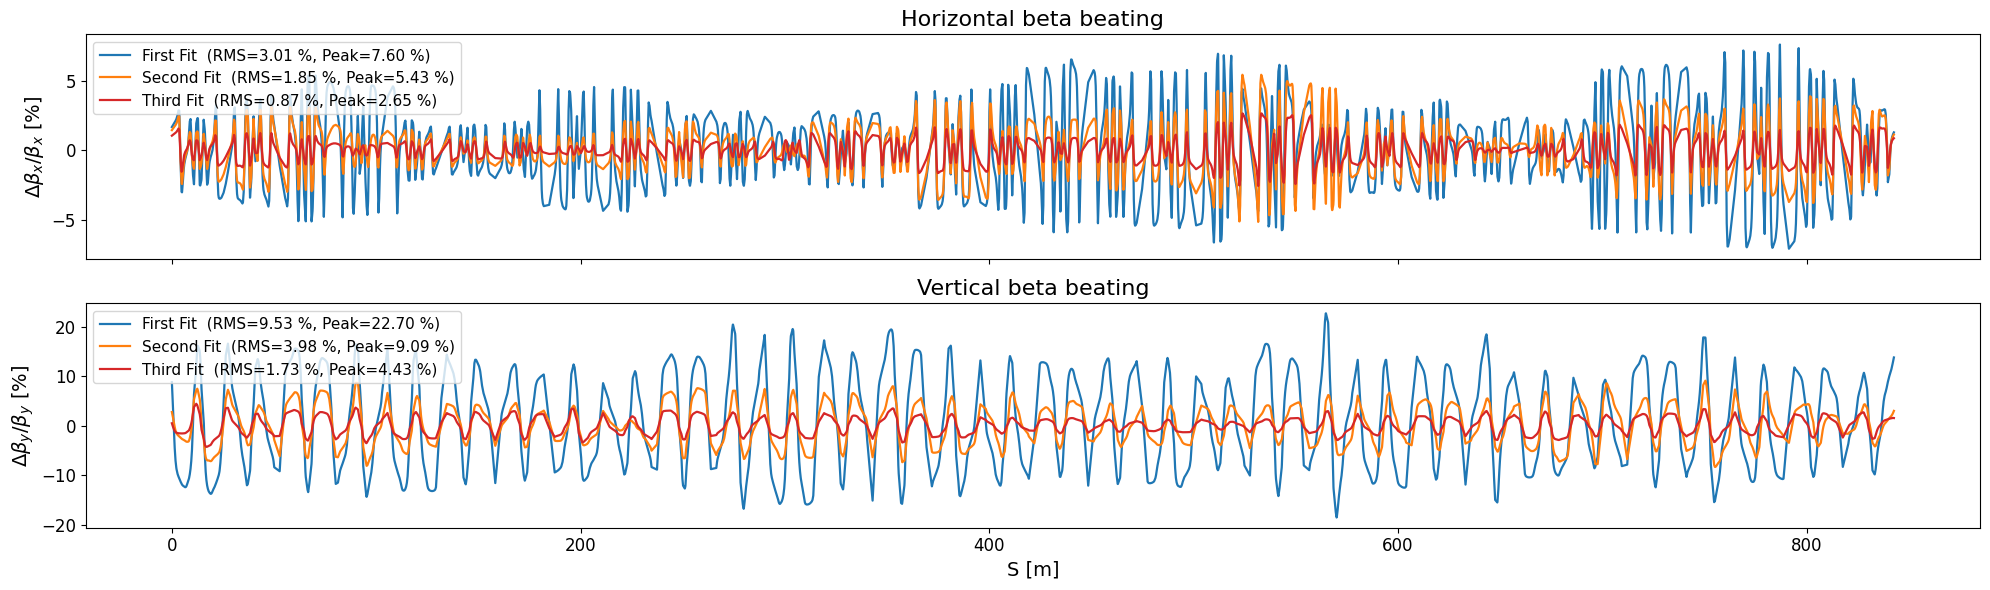

In [65]:
plot_beta_iterations(
    s_pos,
    bx_list=[bx1, bx2, bx3],
    by_list=[by1, by2, by3],
    labels=[
        "First Fit",
        "Second Fit",
        "Third Fit",
    ]
)
